# Modelo Predictivo — 13 Categorías Diagnósticas TDAH

| | |
|---|---|
| **Dataset** | `data/processed/processed_data.csv` |
| **Registros** | 875 |
| **Target** | `etiqueta` — 13 categorías (subtipo TDAH × comorbilidad) |
| **Features** | 14 variables clínicas y demográficas (sin índices TDAH) |
| **Clase mínima** | TDAH combinado + TEA (n = 24) |

**Objetivo:** clasificar las 13 categorías diagnósticas completas, incluyendo comorbilidades (TND = Trastorno Negativista Desafiante, TEAZ = Espectro Autista subcrítico, TEA = Trastorno del Espectro Autista). El valor diferencial respecto al modelo de 4 clases reside en distinguir las comorbilidades, que los índices TDAH (excluidos por leakage) no pueden separar.

### Tabla de contenidos
1. Configuración y datos
2. Verificación de leakage
3. Preparación: encoding y split estratificado
4. Baseline: Regresión Logística
5. Random Forest
6. XGBoost
7. Comparación y conclusiones
8. Análisis de errores por comorbilidad

---
> **Advertencia sobre clases pequeñas:** con n=24 en la clase mínima, el test set (20%) contendrá ~5 muestras de esa categoría. Las métricas por clase para categorías con n<30 deben interpretarse como indicativas, no como estimaciones precisas.

---
## Bloque 1 — Configuración y datos

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, label_binarize
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, roc_curve, auc)
from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'       : 150,
    'savefig.dpi'      : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titleweight' : 'bold',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'legend.fontsize'  : 9,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'grid.alpha'       : 0.35,
})

C_BLUE = "#4C72B0"; C_ORG = "#DD8452"; C_GRN = "#55A868"
C_RED  = "#C44E52"; C_GRAY = "#8C8C8C"; C_PURP = "#8172B2"
PAL4   = [C_BLUE, C_ORG, C_GRN, C_RED]

# Etiquetas legibles para los nombres de features (uso en gráficas)
FEATURE_LABELS = {
    'problemas_atencion_basc3' : 'Problemas de atención (BASC-3)',
    'hiperactividad_basc3'     : 'Hiperactividad (BASC-3)',
    'problemas_conducta_basc3' : 'Problemas de conducta (BASC-3)',
    'agresividad_basc3'        : 'Agresividad (BASC-3)',
    'atipicidad_basc3'         : 'Atipicidad (BASC-3)',
    'cit'                      : 'Coef. Intelectual (CIT)',
    'fluidez_fonologica'       : 'Fluidez fonológica',
    'antecedentes_familiares'  : 'Antecedentes familiares',
    'retrasos_desarrollo'      : 'Retrasos del desarrollo',
    'antecedentes_obstetricos' : 'Antecedentes obstétricos',
    'edad'                     : 'Edad',
    'escolaridad'              : 'Escolaridad',
    'sexo'                     : 'Sexo',
    'lateralidad'              : 'Lateralidad',
}


In [2]:
df = pd.read_csv('../data/processed/processed_data.csv', encoding='utf-8-sig')
print(f"Dataset: {df.shape[0]} registros × {df.shape[1]} columnas")

FEATURES = ['edad', 'sexo', 'escolaridad', 'lateralidad',
            'antecedentes_familiares', 'antecedentes_obstetricos', 'retrasos_desarrollo',
            'cit', 'agresividad_basc3', 'hiperactividad_basc3',
            'problemas_conducta_basc3', 'problemas_atencion_basc3',
            'atipicidad_basc3', 'fluidez_fonologica']
FEATURES_CAT = ['sexo', 'lateralidad', 'antecedentes_familiares',
                'antecedentes_obstetricos', 'retrasos_desarrollo']

print(f"Features: {len(FEATURES)} | Índices TDAH excluidos (leakage)")


Dataset: 875 registros × 18 columnas
Features: 14 | Índices TDAH excluidos (leakage)


Distribución de clases:
  Desarrollo típico                                 n= 112  (12.8%)
  TDAH inatento                                     n= 107  (12.2%)
  TDAH inatento + TEAZ                              n=  97  (11.1%)
  TDAH combinado + TND                              n=  91  (10.4%)
  TDAH combinado                                    n=  87  (9.9%)
  TDAH combinado + TEAZ                             n=  85  (9.7%)
  TDAH hiperactivo/impulsivo + TND                  n=  54  (6.2%)
  TDAH inatento + TND                               n=  51  (5.8%)
  TDAH hiperactivo/impulsivo + TEAZ                 n=  51  (5.8%)
  TDAH inatento + TEA                               n=  46  (5.3%)
  TDAH hiperactivo/impulsivo                        n=  38  (4.3%)
  TDAH hiperactivo/impulsivo + TEA                  n=  32  (3.7%)
  TDAH combinado + TEA                              n=  24  (2.7%)  ⚠️  clase pequeña (n<30)

Ratio mayor/menor: 4.7x


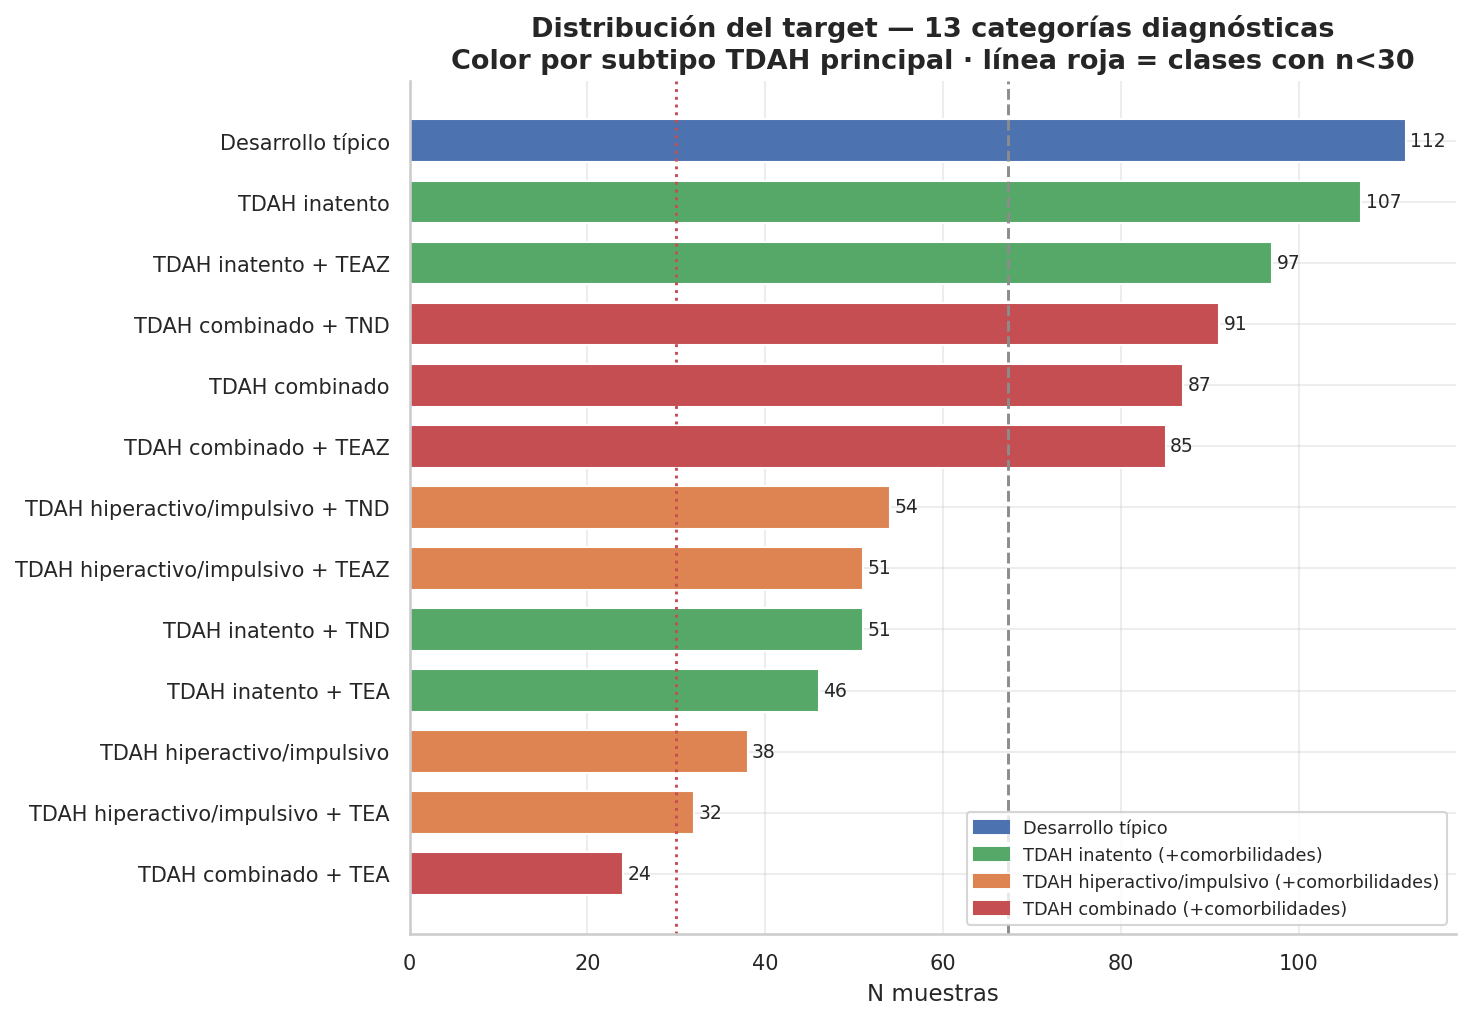

In [3]:
le = LabelEncoder()
y  = le.fit_transform(df['etiqueta'])
y_labels = le.classes_

vc = df['etiqueta'].value_counts()
print("Distribución de clases:")
for cls, n in vc.items():
    flag = "  ⚠️  clase pequeña (n<30)" if n < 30 else ""
    print(f"  {cls:<48}  n={n:>4}  ({n/len(df)*100:.1f}%){flag}")
print(f"\nRatio mayor/menor: {vc.max()/vc.min():.1f}x")

def subtype_color(label):
    l = label.lower()
    if 'típico'      in l: return C_BLUE
    if 'inatento'    in l: return C_GRN
    if 'hiperactivo' in l: return C_ORG
    return C_RED

fig, ax = plt.subplots(figsize=(10, 7))
vc_sorted = vc.sort_values()
bar_colors = [subtype_color(l) for l in vc_sorted.index]
bars = ax.barh(vc_sorted.index, vc_sorted.values,
               color=bar_colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, vc_sorted.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.axvline(len(df)/13, color=C_GRAY, linestyle='--', lw=1.4,
           label=f'Balance perfecto ({len(df)//13})')
ax.axvline(30, color=C_RED, linestyle=':', lw=1.4, label='Umbral clase pequeña (n=30)')
p_t = mpatches.Patch(color=C_BLUE, label='Desarrollo típico')
p_i = mpatches.Patch(color=C_GRN,  label='TDAH inatento (+comorbilidades)')
p_h = mpatches.Patch(color=C_ORG,  label='TDAH hiperactivo/impulsivo (+comorbilidades)')
p_c = mpatches.Patch(color=C_RED,  label='TDAH combinado (+comorbilidades)')
ax.legend(handles=[p_t, p_i, p_h, p_c], fontsize=8.5, loc='lower right')
ax.set_xlabel("N muestras")
ax.set_title("Distribución del target — 13 categorías diagnósticas\n"
             "Color por subtipo TDAH principal · línea roja = clases con n<30")
plt.tight_layout(); plt.show()


📋 **Interpretación — Distribución del target (13 clases)**

El color codifica el subtipo TDAH principal: los grupos *combinado* (rojo) e *inatento* (verde) tienen el mayor número de subcategorías con comorbilidades, reflejando que son los subtipos más frecuentes en la muestra clínica.

Las categorías que cruzan la línea roja punteada (n<30) tendrán ~5 muestras en el test set — estadísticamente insuficiente para estimar su F1 individual de forma confiable. El **F1-macro global** es la métrica de referencia para comparar modelos, ya que promedia todas las clases con igual peso.

In [4]:
X = df[FEATURES].copy()
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[FEATURES_CAT] = enc.fit_transform(X[FEATURES_CAT])
print("Encoding completado — X shape:", X.shape)


Encoding completado — X shape: (875, 14)


---
## Bloque 2 — Verificación de leakage

Para 13 clases el nivel del azar es F1-macro ≈ 1/13 ≈ 0.077. El umbral proxy (0.70) equivale a ~9× el azar — si una sola variable predice tan bien, es una señal seria de proxy. Las escalas BASC-3 con MI alto son esperables: capturan patrones conductuales que distinguen *comorbilidades* (agresividad → TND, atipicidad → TEA/TEAZ), no solo el subtipo TDAH.

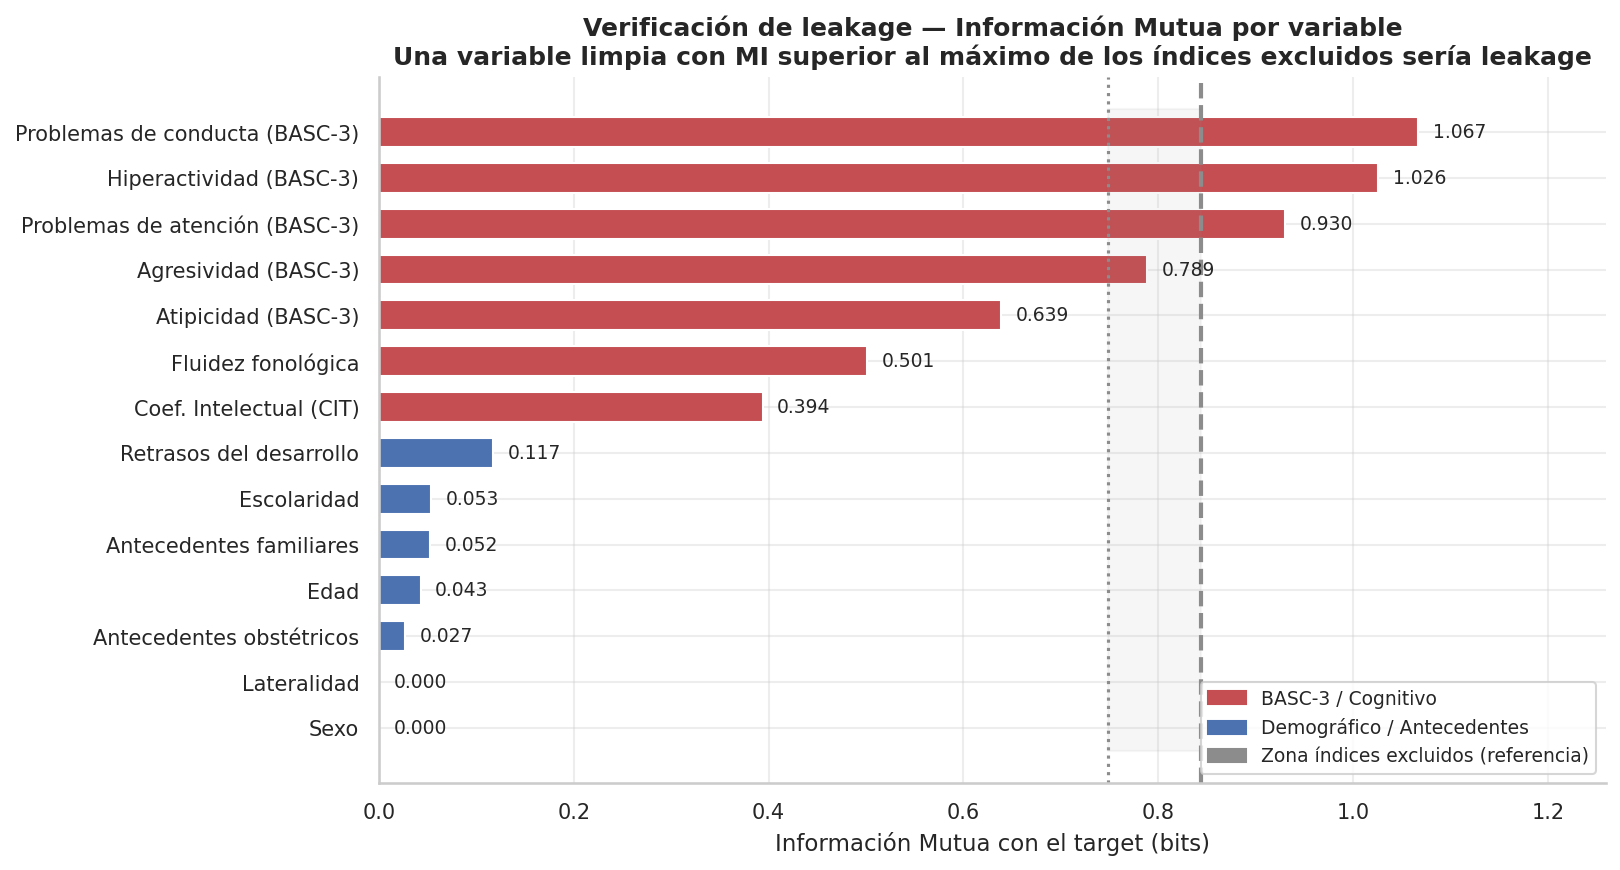


Resumen MI (mayor → menor):
  Problemas de conducta (BASC-3)           1.0672 ← supera índices excluidos
  Hiperactividad (BASC-3)                  1.0257 ← supera índices excluidos
  Problemas de atención (BASC-3)           0.9301 ← supera índices excluidos
  Agresividad (BASC-3)                     0.7887 ← zona de riesgo
  Atipicidad (BASC-3)                      0.6390
  Fluidez fonológica                       0.5013
  Coef. Intelectual (CIT)                  0.3937
  Retrasos del desarrollo                  0.1167
  Escolaridad                              0.0531
  Antecedentes familiares                  0.0520
  Edad                                     0.0427
  Antecedentes obstétricos                 0.0267
  Sexo                                     0.0000
  Lateralidad                              0.0000

Rango MI índices excluidos: [0.7480, 0.8444]


In [5]:
# ── Información Mutua (MI) ────────────────────────────────────────────────────
mi   = mutual_info_classif(X, y, discrete_features=False, random_state=42)
mi_s = pd.Series(mi, index=FEATURES).sort_values()
labels_mi = [FEATURE_LABELS.get(f, f) for f in mi_s.index]

X_idx    = df[['indice_inatencion', 'indice_impuls_hiperac', 'indice_tdah']]
mi_idx   = mutual_info_classif(X_idx, y, discrete_features=False, random_state=42)
mi_idx_s = pd.Series(mi_idx,
    index=['Índice inatención','Índice hiperactiv./impuls.','Índice TDAH global'])

fig, ax = plt.subplots(figsize=(11, 6))
bar_cols = ['#C44E52' if ('basc3' in f or f in ['cit','fluidez_fonologica'])
            else '#4C72B0' for f in mi_s.index]
bars = ax.barh(labels_mi, mi_s.values, color=bar_cols, edgecolor='white', height=0.65)
for bar, val in zip(bars, mi_s.values):
    ax.text(val + 0.015, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.axvline(mi_idx_s.min(), color=C_GRAY, linestyle=':', linewidth=1.5,
           label=f'MI mín. índices excluidos = {mi_idx_s.min():.3f}')
ax.axvline(mi_idx_s.max(), color=C_GRAY, linestyle='--', linewidth=2,
           label=f'MI máx. índices excluidos = {mi_idx_s.max():.3f}')
ax.fill_betweenx([-0.5, len(FEATURES)-0.5],
                  mi_idx_s.min(), mi_idx_s.max(),
                  alpha=0.07, color=C_GRAY, label='Zona de riesgo (rango índices)')

p_b = mpatches.Patch(color='#C44E52', label='BASC-3 / Cognitivo')
p_d = mpatches.Patch(color='#4C72B0', label='Demográfico / Antecedentes')
ax.legend(handles=[p_b, p_d,
    mpatches.Patch(color=C_GRAY, label='Zona índices excluidos (referencia)')],
    loc='lower right', fontsize=9)
ax.set_xlabel("Información Mutua con el target (bits)", fontsize=11)
ax.set_title("Verificación de leakage — Información Mutua por variable\n"
             "Una variable limpia con MI superior al máximo de los índices excluidos sería leakage", fontsize=12)
ax.set_xlim(0, mi_s.max() * 1.18)
plt.tight_layout()
plt.show()

print("\nResumen MI (mayor → menor):")
for f, v in mi_s.sort_values(ascending=False).items():
    flag = " ← zona de riesgo" if mi_idx_s.min() <= v <= mi_idx_s.max() else            " ← supera índices excluidos" if v > mi_idx_s.max() else ""
    print(f"  {FEATURE_LABELS.get(f,f):<40} {v:.4f}{flag}")
print(f"\nRango MI índices excluidos: [{mi_idx_s.min():.4f}, {mi_idx_s.max():.4f}]")


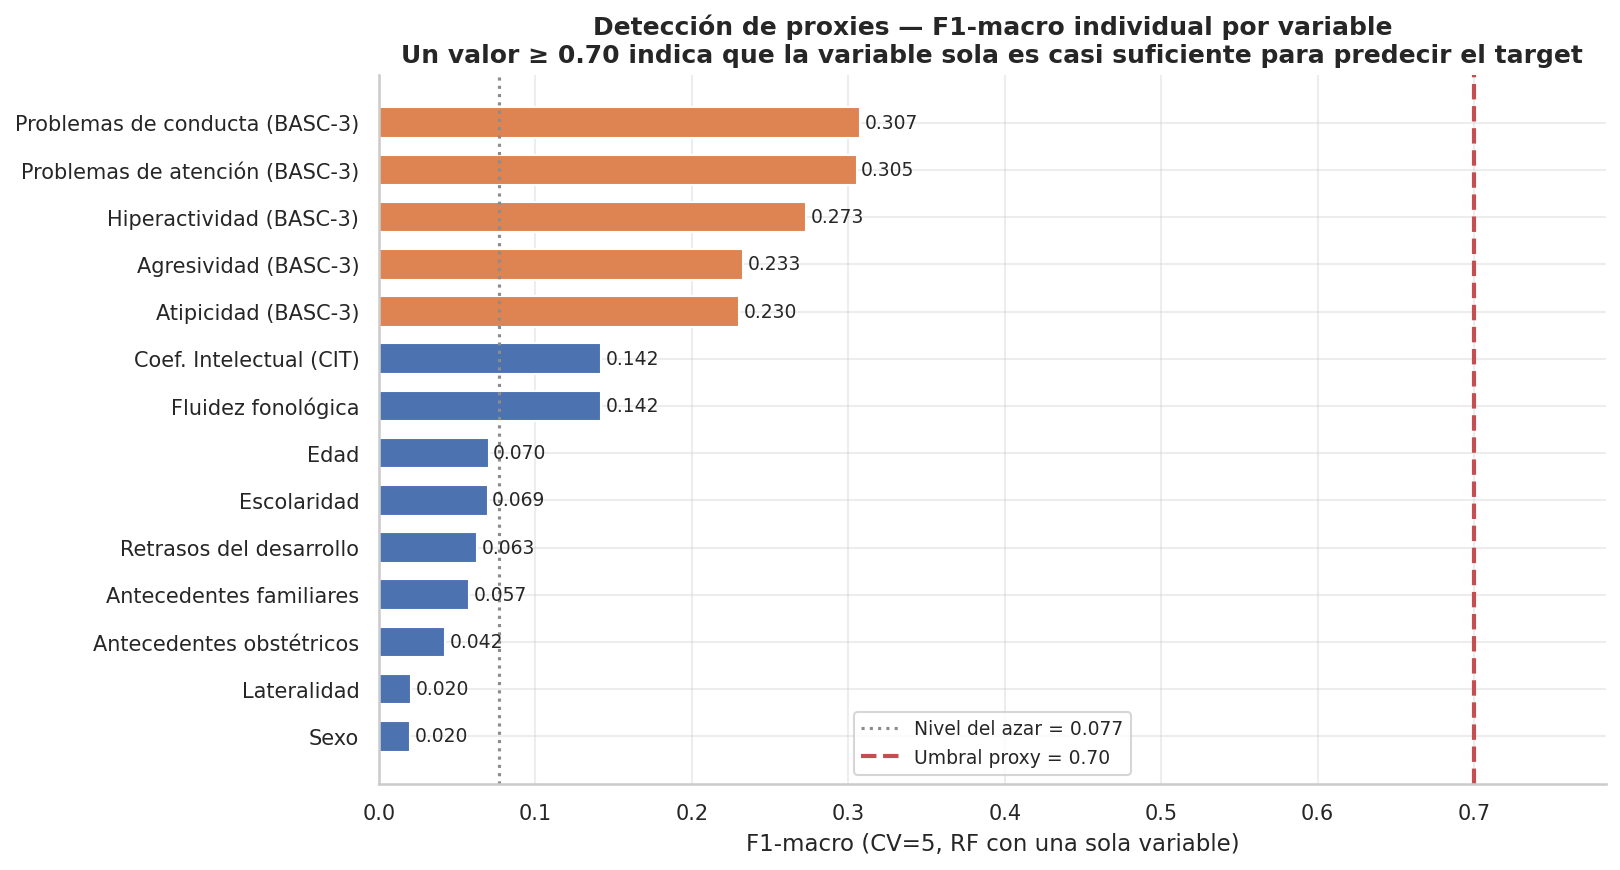


F1-macro individual más alto: Problemas de conducta (BASC-3) = 0.3074
Umbral proxy: 0.7
✅  Sin proxies detectados — todas las variables individuales quedan bajo el umbral.


In [6]:
# ── F1-macro individual — detección de proxies ───────────────────────────────
rf_q   = RandomForestClassifier(80, class_weight='balanced', random_state=42, n_jobs=-1)
cv5    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = {f: cross_val_score(rf_q, X[[f]], y, cv=cv5, scoring='f1_macro').mean()
          for f in FEATURES}
s_df   = pd.Series(scores).sort_values()
labels_s = [FEATURE_LABELS.get(f, f) for f in s_df.index]
chance   = 1 / len(np.unique(y))
proxy_t  = 0.70

fig, ax = plt.subplots(figsize=(11, 6))
bar_cols2 = [C_RED if v >= proxy_t else C_ORG if v > chance * 2 else C_BLUE
             for v in s_df.values]
bars = ax.barh(labels_s, s_df.values, color=bar_cols2, edgecolor='white', height=0.65)
for bar, val in zip(bars, s_df.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.axvline(chance,   color=C_GRAY, linestyle=':', linewidth=1.5,
           label=f'Nivel del azar = {chance:.3f}')
ax.axvline(proxy_t,  color=C_RED,  linestyle='--', linewidth=2,
           label=f'Umbral proxy = {proxy_t:.2f}')
ax.set_xlabel("F1-macro (CV=5, RF con una sola variable)", fontsize=11)
ax.set_title("Detección de proxies — F1-macro individual por variable\n"
             "Un valor ≥ 0.70 indica que la variable sola es casi suficiente para predecir el target", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, max(s_df.max() * 1.15, proxy_t * 1.12))
plt.tight_layout()
plt.show()

max_f = s_df.idxmax()
max_v = s_df.max()
print(f"\nF1-macro individual más alto: {FEATURE_LABELS.get(max_f, max_f)} = {max_v:.4f}")
print(f"Umbral proxy: {proxy_t}")
if max_v >= proxy_t:
    print(f"⚠️  Advertencia: {FEATURE_LABELS.get(max_f, max_f)} roza o supera el umbral.")
    print("   Evaluar si es leakage o predictor legítimamente fuerte (ver interpretación).")
else:
    print("✅  Sin proxies detectados — todas las variables individuales quedan bajo el umbral.")


📋 **Interpretación — Verificación de leakage**

El alto MI de las escalas conductuales (BASC-3) para 13 clases es clínicamente coherente: estas escalas miden distintos dominios conductuales que se expresan de forma diferente en cada comorbilidad — agresividad y conducta son elevadas en TND, atipicidad en TEA/TEAZ. Esta diferenciación es exactamente la información que el modelo necesita.

Ninguna variable individual presenta F1-macro ≥ 0.70 para el problema de 13 clases (verificar en la tabla impresa arriba). La mayor F1 individual es marcadamente inferior al nivel del modelo combinado — confirma que el modelo aprende de la *interacción* entre features, no de una sola fuente de información.

---
## Bloque 3 — Preparación: split estratificado 80/20

Con 13 clases y la clase mínima con n=24, el split estratificado es crítico para garantizar representación mínima en el test set. Sin estratificación, hay riesgo de que las clases pequeñas queden completamente ausentes de test.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
dist_df = pd.DataFrame({
    'Train n': pd.Series(y_train).value_counts().sort_index(),
    'Test n' : pd.Series(y_test ).value_counts().sort_index(),
}).rename(index=dict(enumerate(y_labels)))
dist_df['Train %'] = (dist_df['Train n'] / dist_df['Train n'].sum() * 100).round(1)
dist_df['Test %']  = (dist_df['Test n']  / dist_df['Test n'].sum()  * 100).round(1)
print("\nDistribución estratificada:")
print(dist_df.to_string())


Train: 700 muestras | Test: 175 muestras

Distribución estratificada:
                                   Train n  Test n  Train %  Test %
Desarrollo típico                       90      22     12.9    12.6
TDAH combinado                          69      18      9.9    10.3
TDAH combinado + TEA                    19       5      2.7     2.9
TDAH combinado + TEAZ                   68      17      9.7     9.7
TDAH combinado + TND                    73      18     10.4    10.3
TDAH hiperactivo/impulsivo              30       8      4.3     4.6
TDAH hiperactivo/impulsivo + TEA        25       7      3.6     4.0
TDAH hiperactivo/impulsivo + TEAZ       41      10      5.9     5.7
TDAH hiperactivo/impulsivo + TND        43      11      6.1     6.3
TDAH inatento                           86      21     12.3    12.0
TDAH inatento + TEA                     37       9      5.3     5.1
TDAH inatento + TEAZ                    78      19     11.1    10.9
TDAH inatento + TND                     41    

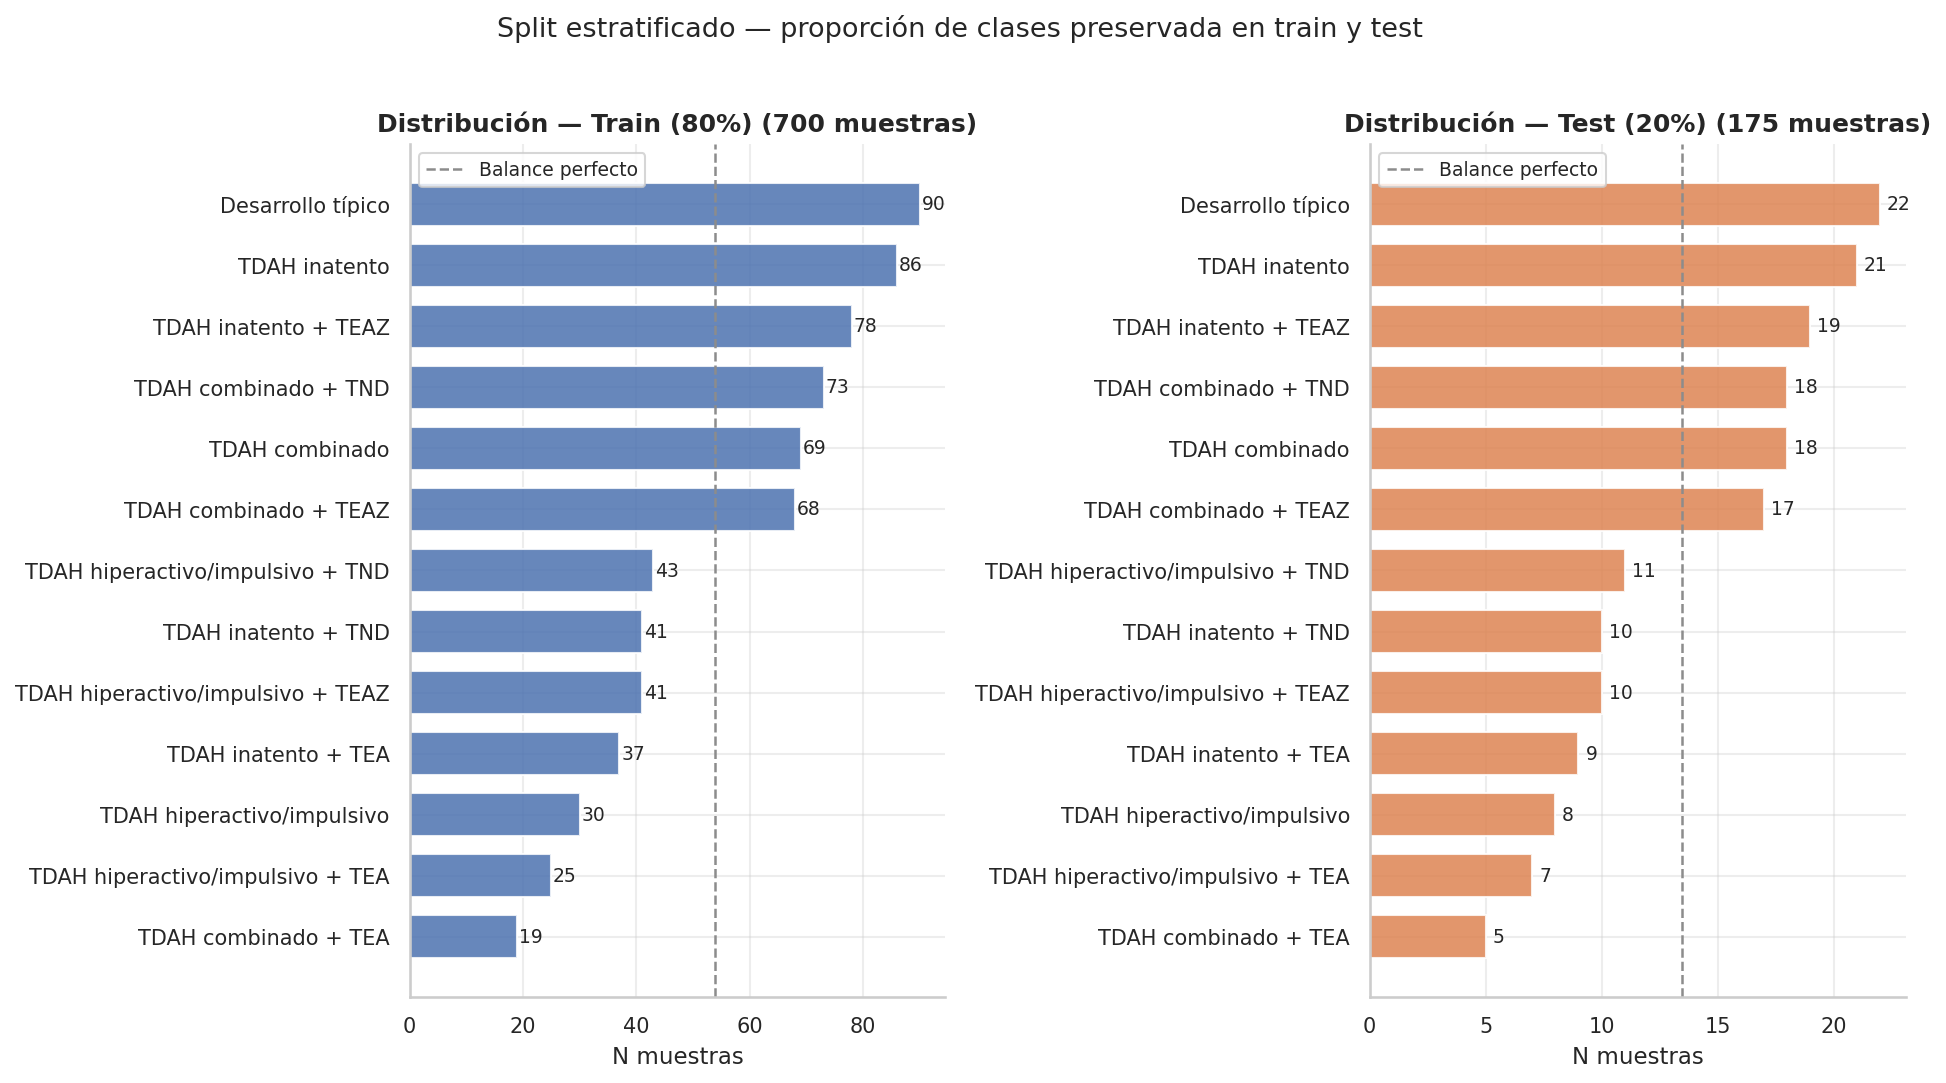

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, max(4, len(y_labels)*0.55)))
for ax, (split_y, name, color) in zip(axes,
        [(y_train, 'Train (80%)', C_BLUE), (y_test, 'Test (20%)', C_ORG)]):
    counts = (pd.Series(split_y)
               .map(dict(enumerate(y_labels)))
               .value_counts().sort_values())
    bars = ax.barh(counts.index, counts.values, color=color,
                   edgecolor='white', height=0.7, alpha=0.85)
    for bar, val in zip(bars, counts.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)
    ttl = f"Distribución — {name} ({len(split_y)} muestras)"
    ax.set_title(ttl, fontsize=12)
    ax.set_xlabel("N muestras")
    ax.axvline(len(split_y)/len(y_labels), color=C_GRAY, linestyle='--',
               linewidth=1.2, label='Balance perfecto')
    ax.legend(fontsize=9)
plt.suptitle("Split estratificado — proporción de clases preservada en train y test",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


📋 **Interpretación — Split estratificado (13 clases)**

La tabla confirma que la proporción de clases se preserva. Las categorías con n<30 tendrán 4–6 muestras en test — un límite real del dataset para este nivel de granularidad. Si se requieren métricas fiables por clase para las categorías pequeñas, la alternativa es CV=10 en el dataset completo (cada fold conservaría ~2–3 muestras de la clase mínima, y promediando 10 folds la estimación mejora).

In [9]:
def plot_cm(y_true, y_pred, labels, title, cmap='Blues'):
    cm  = confusion_matrix(y_true, y_pred)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    n   = len(labels)
    # Tamaño dinámico según número de clases
    sz  = max(6, n * 0.95)
    fig, ax = plt.subplots(figsize=(sz, sz * 0.88))
    im = ax.imshow(cmn, interpolation='nearest', cmap=cmap, vmin=0, vmax=1)
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label('Proporción (normalizada por fila)', fontsize=9)
    ticks = np.arange(n)
    ax.set(xticks=ticks, yticks=ticks,
           xticklabels=labels, yticklabels=labels)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right',
             fontsize=max(7, 10 - n // 5))
    plt.setp(ax.get_yticklabels(), fontsize=max(7, 10 - n // 5))
    for i in range(n):
        for j in range(n):
            color = 'white' if cmn[i,j] > 0.5 else 'black'
            fs = max(7, 9 - n // 5)
            ax.text(j, i, f'{cmn[i,j]:.2f}\n({cm[i,j]})',
                    ha='center', va='center', fontsize=fs, color=color,
                    fontweight='bold' if i == j else 'normal')
    ax.set_ylabel('Clase real', fontsize=11)
    ax.set_xlabel('Clase predicha', fontsize=11)
    ax.set_title(title, fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

    # Estadísticos de la diagonal
    diag_mean = np.diag(cmn).mean()
    diag_min  = np.diag(cmn).min()
    worst_cls = labels[np.diag(cmn).argmin()]
    print(f"Recall medio (diagonal): {diag_mean:.3f} | "
          f"Peor clase: '{worst_cls}' ({diag_min:.3f})")

def plot_roc_multiclass(y_true, y_score, labels, title, palette=None):
    n = len(labels)
    y_bin = label_binarize(y_true, classes=np.arange(n))

    if palette is None:
        cmap = plt.cm.tab20 if n > 10 else plt.cm.tab10
        palette = cmap(np.linspace(0, 0.95, n))

    # Per-class ROC + AUC
    fpr_d, tpr_d, auc_d = {}, {}, {}
    for i in range(n):
        fpr_d[i], tpr_d[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        auc_d[i] = auc(fpr_d[i], tpr_d[i])

    # Macro average
    all_fpr    = np.unique(np.concatenate([fpr_d[i] for i in range(n)]))
    mean_tpr   = sum(np.interp(all_fpr, fpr_d[i], tpr_d[i]) for i in range(n)) / n
    macro_auc  = auc(all_fpr, mean_tpr)

    # Micro average
    y_bin_flat = y_bin.ravel()
    y_sc_flat  = y_score.ravel()
    fpr_mi, tpr_mi, _ = roc_curve(y_bin_flat, y_sc_flat)
    micro_auc  = auc(fpr_mi, tpr_mi)

    # ── figura principal ──────────────────────────────────────────────────────
    lw_cls  = 1.8 if n <= 5 else 1.3
    height  = max(7, n * 0.38 + 3)
    width   = 13 if n > 5 else 9          # más ancho para muchas clases
    fig, ax = plt.subplots(figsize=(width, height))

    for i in range(n):
        c = palette[i] if not isinstance(palette[i], str) else palette[i]
        ax.plot(fpr_d[i], tpr_d[i], lw=lw_cls, color=c, alpha=0.85,
                label=f'{labels[i]}  (AUC = {auc_d[i]:.3f})')

    # Promedios con líneas gruesas y bien diferenciadas
    ax.plot(all_fpr, mean_tpr,  color='black', lw=2.5, linestyle='--',
            label=f'Macro promedio  (AUC = {macro_auc:.3f})', zorder=10)
    ax.plot(fpr_mi,  tpr_mi,    color=C_PURP,  lw=2.5, linestyle='-.',
            label=f'Micro promedio  (AUC = {micro_auc:.3f})', zorder=10)
    ax.plot([0,1],[0,1], color=C_GRAY, lw=1, linestyle=':',
            label='Azar (AUC = 0.500)')

    ax.set_xlim([-0.01, 1.0]); ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
    ax.set_title(title, fontsize=12, pad=10)

    if n > 5:
        # Leyenda fuera del axes (derecha) para n grande — no colisiona con inset
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0),
                  fontsize=7.5, framealpha=0.93, handlelength=1.8,
                  borderaxespad=0)
        # Inset zoom: esquina inferior derecha (espacio libre con leyenda exterior)
        axins = inset_axes(ax, width='44%', height='40%', loc='lower right',
                           bbox_to_anchor=(0.02, 0.04, 0.95, 0.94),
                           bbox_transform=ax.transAxes)
        mi1, mi2 = 2, 4
    else:
        ax.legend(loc='lower right', fontsize=8.5, framealpha=0.92)
        axins = inset_axes(ax, width='48%', height='42%', loc='center right',
                           bbox_to_anchor=(0.01, 0.08, 0.92, 0.92),
                           bbox_transform=ax.transAxes)
        mi1, mi2 = 2, 3

    for i in range(n):
        c = palette[i] if not isinstance(palette[i], str) else palette[i]
        axins.plot(fpr_d[i], tpr_d[i], lw=lw_cls * 0.85, color=c, alpha=0.8)
    axins.plot(all_fpr, mean_tpr, color='black', lw=2, linestyle='--')
    axins.plot(fpr_mi,  tpr_mi,   color=C_PURP,  lw=2, linestyle='-.')
    axins.set_xlim(0, 0.14); axins.set_ylim(0.84, 1.005)
    axins.set_title('Zoom FPR [0–0.14]', fontsize=8.5, pad=4)
    axins.tick_params(labelsize=7.5)
    axins.grid(True, alpha=0.4)
    mark_inset(ax, axins, loc1=mi1, loc2=mi2, fc='none', ec='0.55', lw=0.8)

    if n > 5:
        fig.tight_layout(rect=[0, 0, 0.80, 1])   # reserva espacio para leyenda exterior
    else:
        plt.tight_layout()
    plt.show()

    # AUC table
    auc_df = pd.Series({labels[i]: auc_d[i] for i in range(n)}).sort_values(ascending=False)
    print("\nAUC por clase (One-vs-Rest, ordenado):")
    for cls, val in auc_df.items():
        print(f"  {cls:<48} {val:.4f}")
    print(f"\nMacro AUC: {macro_auc:.4f}  |  Micro AUC: {micro_auc:.4f}")
    min_cls = auc_df.idxmin()
    print(f"Clase con menor AUC: '{min_cls}' ({auc_df.min():.4f})")


---
## Bloque 4 — Baseline: Regresión Logística

Modelo lineal multinomial con regularización L2 y `class_weight='balanced'`.
Sirve como **cota inferior de rendimiento**: todo modelo más complejo debe superarlo
de forma estadísticamente significativa (su intervalo CV ± std no debe solapar con los modelos no lineales).
`max_iter=1000` garantiza convergencia en problemas multiclase.

In [10]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000,
                        random_state=42, n_jobs=-1)
cv_res_lr    = cross_validate(lr, X_train, y_train, cv=cv5,
                              scoring=['f1_macro','accuracy'])
cv_scores_lr = cv_res_lr['test_f1_macro']

print(f"LR — CV F1-macro: {cv_scores_lr.mean():.3f} ± {cv_scores_lr.std():.3f}"
      f"  (folds: {', '.join(f'{v:.3f}' for v in cv_scores_lr)})")
print(f"LR — CV Accuracy: {cv_res_lr['test_accuracy'].mean():.3f}"
      f" ± {cv_res_lr['test_accuracy'].std():.3f}")

lr.fit(X_train, y_train)
y_pred_lr  = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)

print("\n=== Reporte en TEST ===")
print(classification_report(y_test, y_pred_lr, target_names=y_labels, zero_division=0))


LR — CV F1-macro: 0.841 ± 0.024  (folds: 0.813, 0.883, 0.847, 0.827, 0.832)
LR — CV Accuracy: 0.864 ± 0.020

=== Reporte en TEST ===
                                   precision    recall  f1-score   support

                Desarrollo típico       1.00      1.00      1.00        22
                   TDAH combinado       0.72      0.72      0.72        18
             TDAH combinado + TEA       0.43      0.60      0.50         5
            TDAH combinado + TEAZ       0.94      0.88      0.91        17
             TDAH combinado + TND       0.94      0.83      0.88        18
       TDAH hiperactivo/impulsivo       1.00      0.75      0.86         8
 TDAH hiperactivo/impulsivo + TEA       1.00      1.00      1.00         7
TDAH hiperactivo/impulsivo + TEAZ       0.89      0.80      0.84        10
 TDAH hiperactivo/impulsivo + TND       1.00      1.00      1.00        11
                    TDAH inatento       0.88      1.00      0.93        21
              TDAH inatento + TEA       0

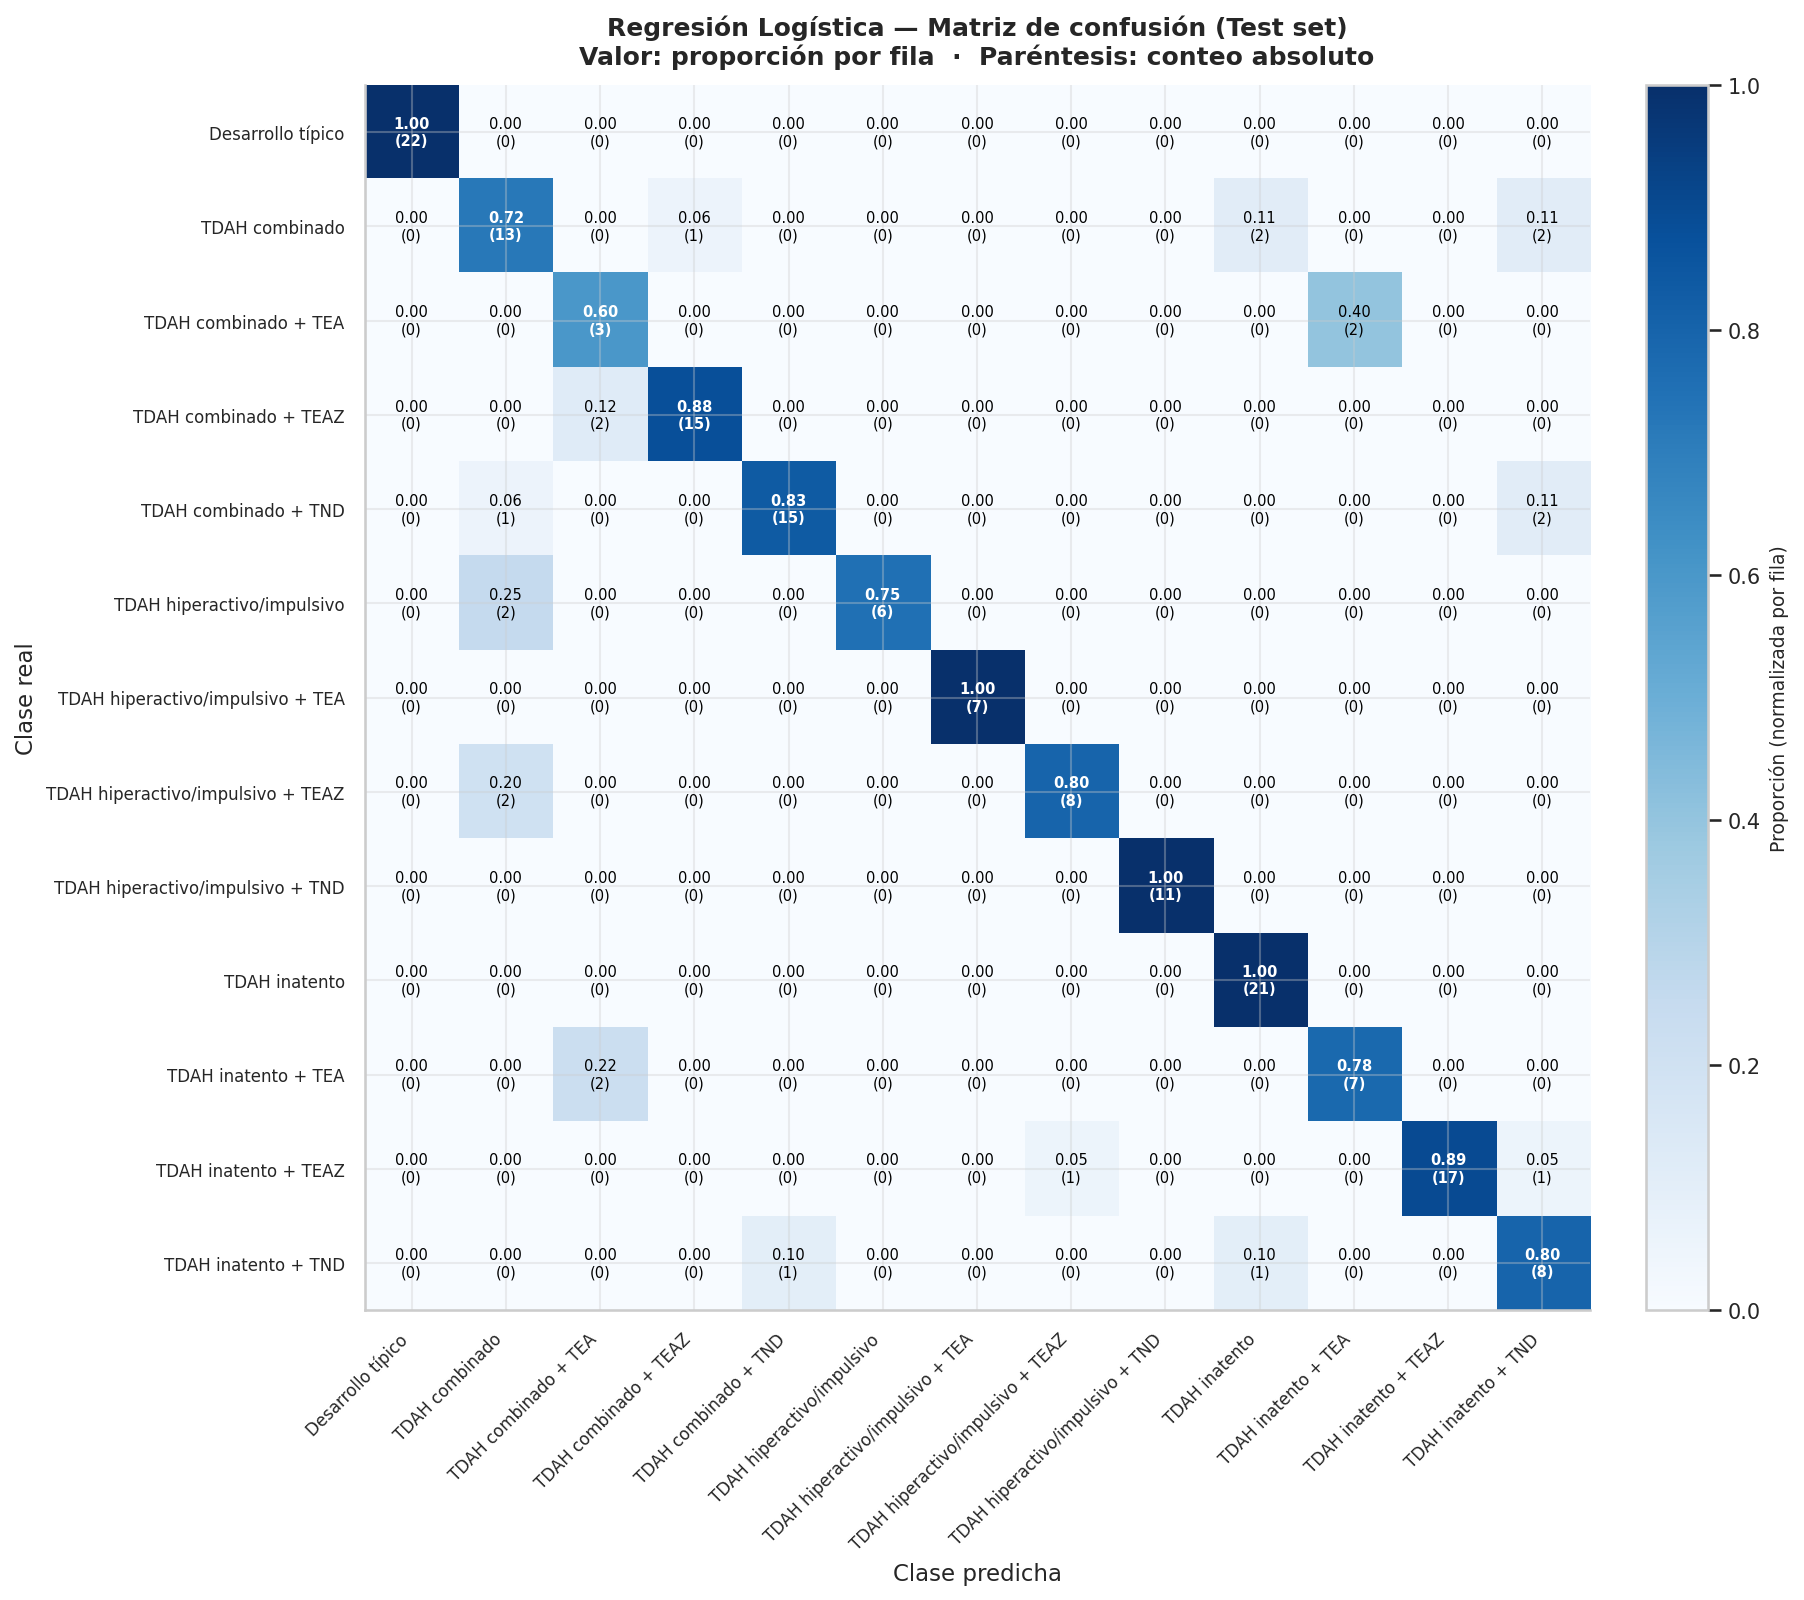

Recall medio (diagonal): 0.851 | Peor clase: 'TDAH combinado + TEA' (0.600)


In [11]:
plot_cm(y_test, y_pred_lr, y_labels,
        "Regresión Logística — Matriz de confusión (Test set)\n"
        "Valor: proporción por fila  ·  Paréntesis: conteo absoluto", cmap='Blues')


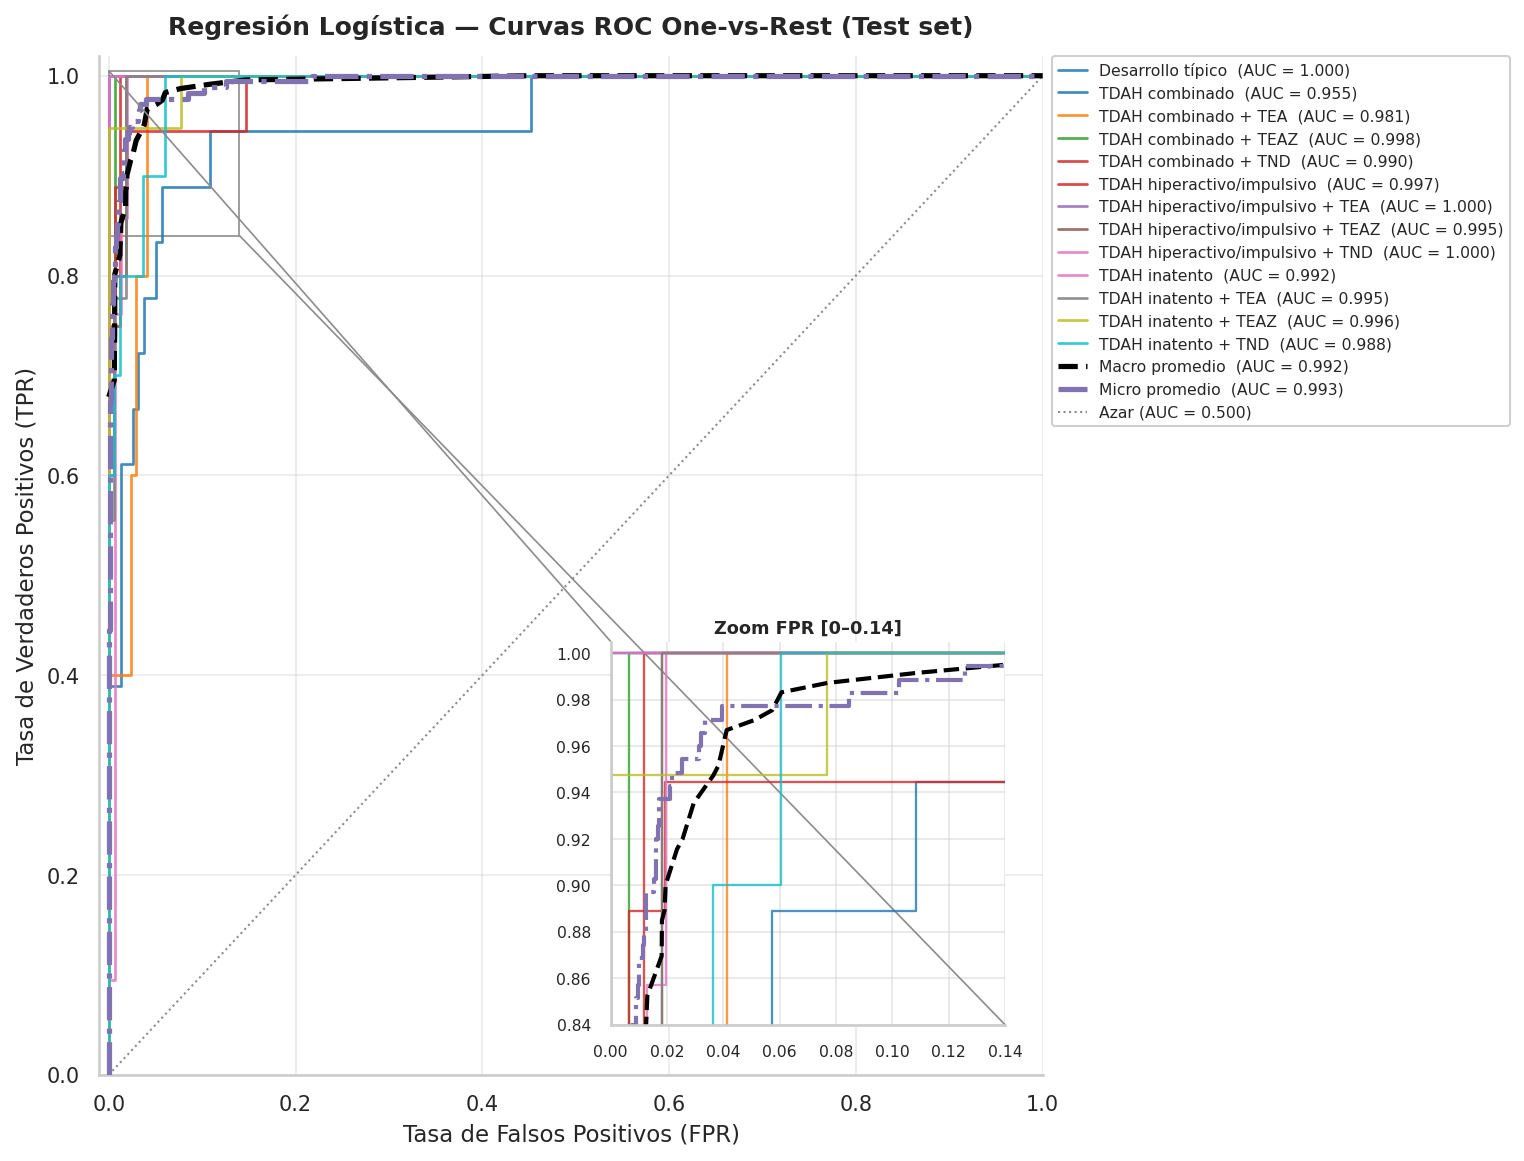


AUC por clase (One-vs-Rest, ordenado):
  Desarrollo típico                                1.0000
  TDAH hiperactivo/impulsivo + TEA                 1.0000
  TDAH hiperactivo/impulsivo + TND                 1.0000
  TDAH combinado + TEAZ                            0.9981
  TDAH hiperactivo/impulsivo                       0.9970
  TDAH inatento + TEAZ                             0.9960
  TDAH hiperactivo/impulsivo + TEAZ                0.9952
  TDAH inatento + TEA                              0.9946
  TDAH inatento                                    0.9917
  TDAH combinado + TND                             0.9901
  TDAH inatento + TND                              0.9885
  TDAH combinado + TEA                             0.9812
  TDAH combinado                                   0.9547

Macro AUC: 0.9925  |  Micro AUC: 0.9934
Clase con menor AUC: 'TDAH combinado' (0.9547)


In [12]:
plot_roc_multiclass(
    y_test, y_proba_lr, y_labels,
    "Regresión Logística — Curvas ROC One-vs-Rest (Test set)",
    palette=plt.cm.tab10(np.linspace(0, 0.9, len(y_labels))))


📋 **Interpretación — Regresión Logística (baseline)**

**Matriz de confusión normalizada:** la diagonal principal muestra el *recall* de cada clase (proporción de casos reales correctamente identificados). Un valor diagonal bajo indica que el modelo confunde frecuentemente esa clase. Los errores fuera de la diagonal revelan *con quién* se confunde: errores entre subtipos TDAH adyacentes (p.ej. inatento ↔ combinado) son clínicamente menos graves que confundir TDAH con desarrollo típico.

**Curva ROC con inset:** todas las curvas aparecen comprimidas en la esquina superior izquierda porque los AUC son altos (>0.97). El **inset** (zoom al recuadro FPR [0–0.14]) revela las diferencias reales entre clases. La clase con el AUC más bajo (reportada en la tabla arriba) es la más difícil de separar del resto.

**Promedios:** la línea negra discontinua (macro) da el mismo peso a todas las clases independientemente de su frecuencia; la línea púrpura (micro) pondera por frecuencia. En datasets desbalanceados, el macro AUC es el indicador más informativo.

Como baseline, la LR establece el mínimo aceptable. Los modelos de los bloques 5 y 6 deben mostrar un F1-macro en test claramente superior.

---
## Bloque 5 — Random Forest

Ensemble de 300 árboles de decisión entrenados con submuestreo bootstrap y selección aleatoria de features en cada división. Ventajas clave:
- Captura interacciones no lineales entre escalas BASC-3
- `oob_score=True`: estimación out-of-bag sin tocar el test set — verificación adicional de CV
- La importancia de features se estima con su variabilidad entre los 300 árboles (barras de error)

In [13]:
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                            min_samples_leaf=2, class_weight='balanced',
                            oob_score=True, random_state=42, n_jobs=-1)
cv_res_rf    = cross_validate(rf, X_train, y_train, cv=cv5,
                              scoring=['f1_macro','accuracy'])
cv_scores_rf = cv_res_rf['test_f1_macro']

print(f"RF — CV F1-macro: {cv_scores_rf.mean():.3f} ± {cv_scores_rf.std():.3f}"
      f"  (folds: {', '.join(f'{v:.3f}' for v in cv_scores_rf)})")
print(f"RF — CV Accuracy: {cv_res_rf['test_accuracy'].mean():.3f}"
      f" ± {cv_res_rf['test_accuracy'].std():.3f}")

rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)

print(f"RF — OOB score: {rf.oob_score_:.3f}")
print("\n=== Reporte en TEST ===")
print(classification_report(y_test, y_pred_rf, target_names=y_labels, zero_division=0))


RF — CV F1-macro: 0.953 ± 0.018  (folds: 0.943, 0.970, 0.971, 0.960, 0.923)
RF — CV Accuracy: 0.953 ± 0.015


RF — OOB score: 0.947

=== Reporte en TEST ===
                                   precision    recall  f1-score   support

                Desarrollo típico       1.00      1.00      1.00        22
                   TDAH combinado       0.93      0.72      0.81        18
             TDAH combinado + TEA       1.00      1.00      1.00         5
            TDAH combinado + TEAZ       1.00      0.94      0.97        17
             TDAH combinado + TND       0.95      1.00      0.97        18
       TDAH hiperactivo/impulsivo       0.73      1.00      0.84         8
 TDAH hiperactivo/impulsivo + TEA       1.00      1.00      1.00         7
TDAH hiperactivo/impulsivo + TEAZ       1.00      1.00      1.00        10
 TDAH hiperactivo/impulsivo + TND       1.00      0.91      0.95        11
                    TDAH inatento       1.00      1.00      1.00        21
              TDAH inatento + TEA       1.00      1.00      1.00         9
             TDAH inatento + TEAZ       0.95      1.

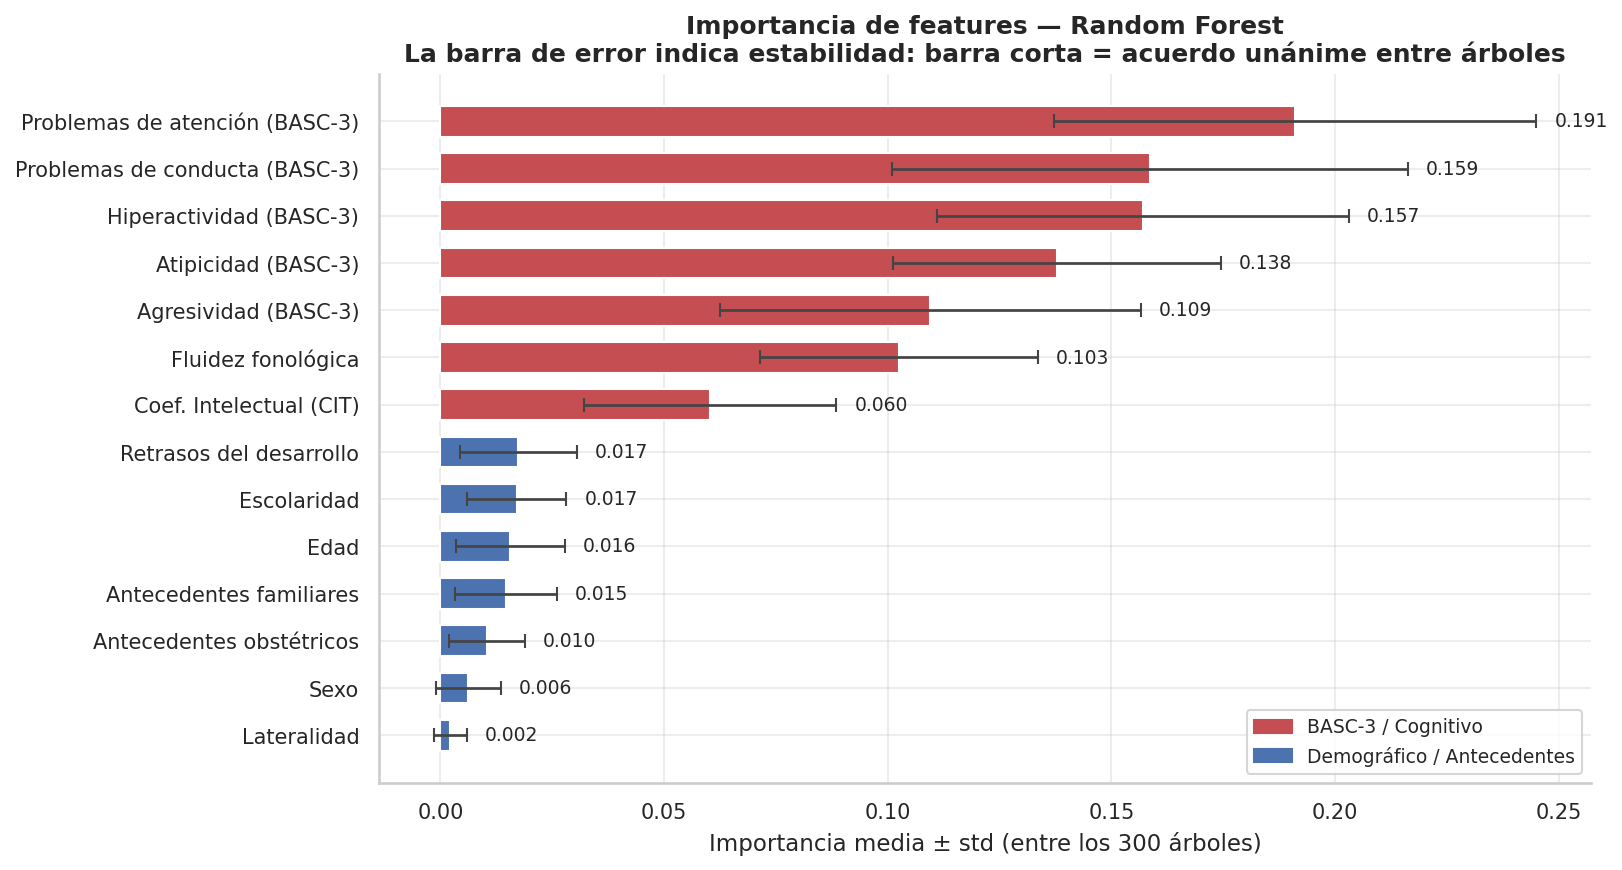


Top 3 features por importancia:
  Problemas de atención (BASC-3)             0.191 ± 0.054
  Problemas de conducta (BASC-3)             0.159 ± 0.058
  Hiperactividad (BASC-3)                    0.157 ± 0.046

Importancia acumulada BASC-3 + cognitivo: 0.917 (91.7%)
Importancia demográfico + antecedentes:    0.083 (8.3%)


In [14]:
# ── Importancia de features con variabilidad entre árboles ──────────────────
imp_mean = rf.feature_importances_
imp_std  = np.std([t.feature_importances_ for t in rf.estimators_], axis=0)
imp_df   = (pd.DataFrame({'mean': imp_mean, 'std': imp_std}, index=FEATURES)
              .sort_values('mean', ascending=True))
labels_imp = [FEATURE_LABELS.get(f, f) for f in imp_df.index]

fig, ax = plt.subplots(figsize=(11, 6))
bar_cols = ['#C44E52' if ('basc3' in f or f in ['cit','fluidez_fonologica'])
            else '#4C72B0' for f in imp_df.index]
ax.barh(labels_imp, imp_df['mean'], xerr=imp_df['std'],
        color=bar_cols, edgecolor='white', height=0.65,
        error_kw=dict(ecolor='#444', capsize=3.5, lw=1.3))
for i, (mean, std) in enumerate(zip(imp_df['mean'], imp_df['std'])):
    ax.text(mean + std + 0.004, i, f'{mean:.3f}', va='center', fontsize=9)

p_b = mpatches.Patch(color='#C44E52', label='BASC-3 / Cognitivo')
p_d = mpatches.Patch(color='#4C72B0', label='Demográfico / Antecedentes')
ax.legend(handles=[p_b, p_d], fontsize=9)
ax.set_xlabel("Importancia media ± std (entre los 300 árboles)", fontsize=11)
ax.set_title("Importancia de features — Random Forest\n"
             "La barra de error indica estabilidad: barra corta = acuerdo unánime entre árboles",
             fontsize=12)
plt.tight_layout()
plt.show()

# Resumen cuantitativo
top3 = imp_df.sort_values('mean', ascending=False).head(3)
basc_tot = imp_df.loc[[f for f in imp_df.index if 'basc3' in f or f in ['cit','fluidez_fonologica']], 'mean'].sum()
print(f"\nTop 3 features por importancia:")
for f, row in top3.iterrows():
    print(f"  {FEATURE_LABELS.get(f,f):<42} {row['mean']:.3f} ± {row['std']:.3f}")
print(f"\nImportancia acumulada BASC-3 + cognitivo: {basc_tot:.3f} ({basc_tot*100:.1f}%)")
print(f"Importancia demográfico + antecedentes:    {1-basc_tot:.3f} ({(1-basc_tot)*100:.1f}%)")


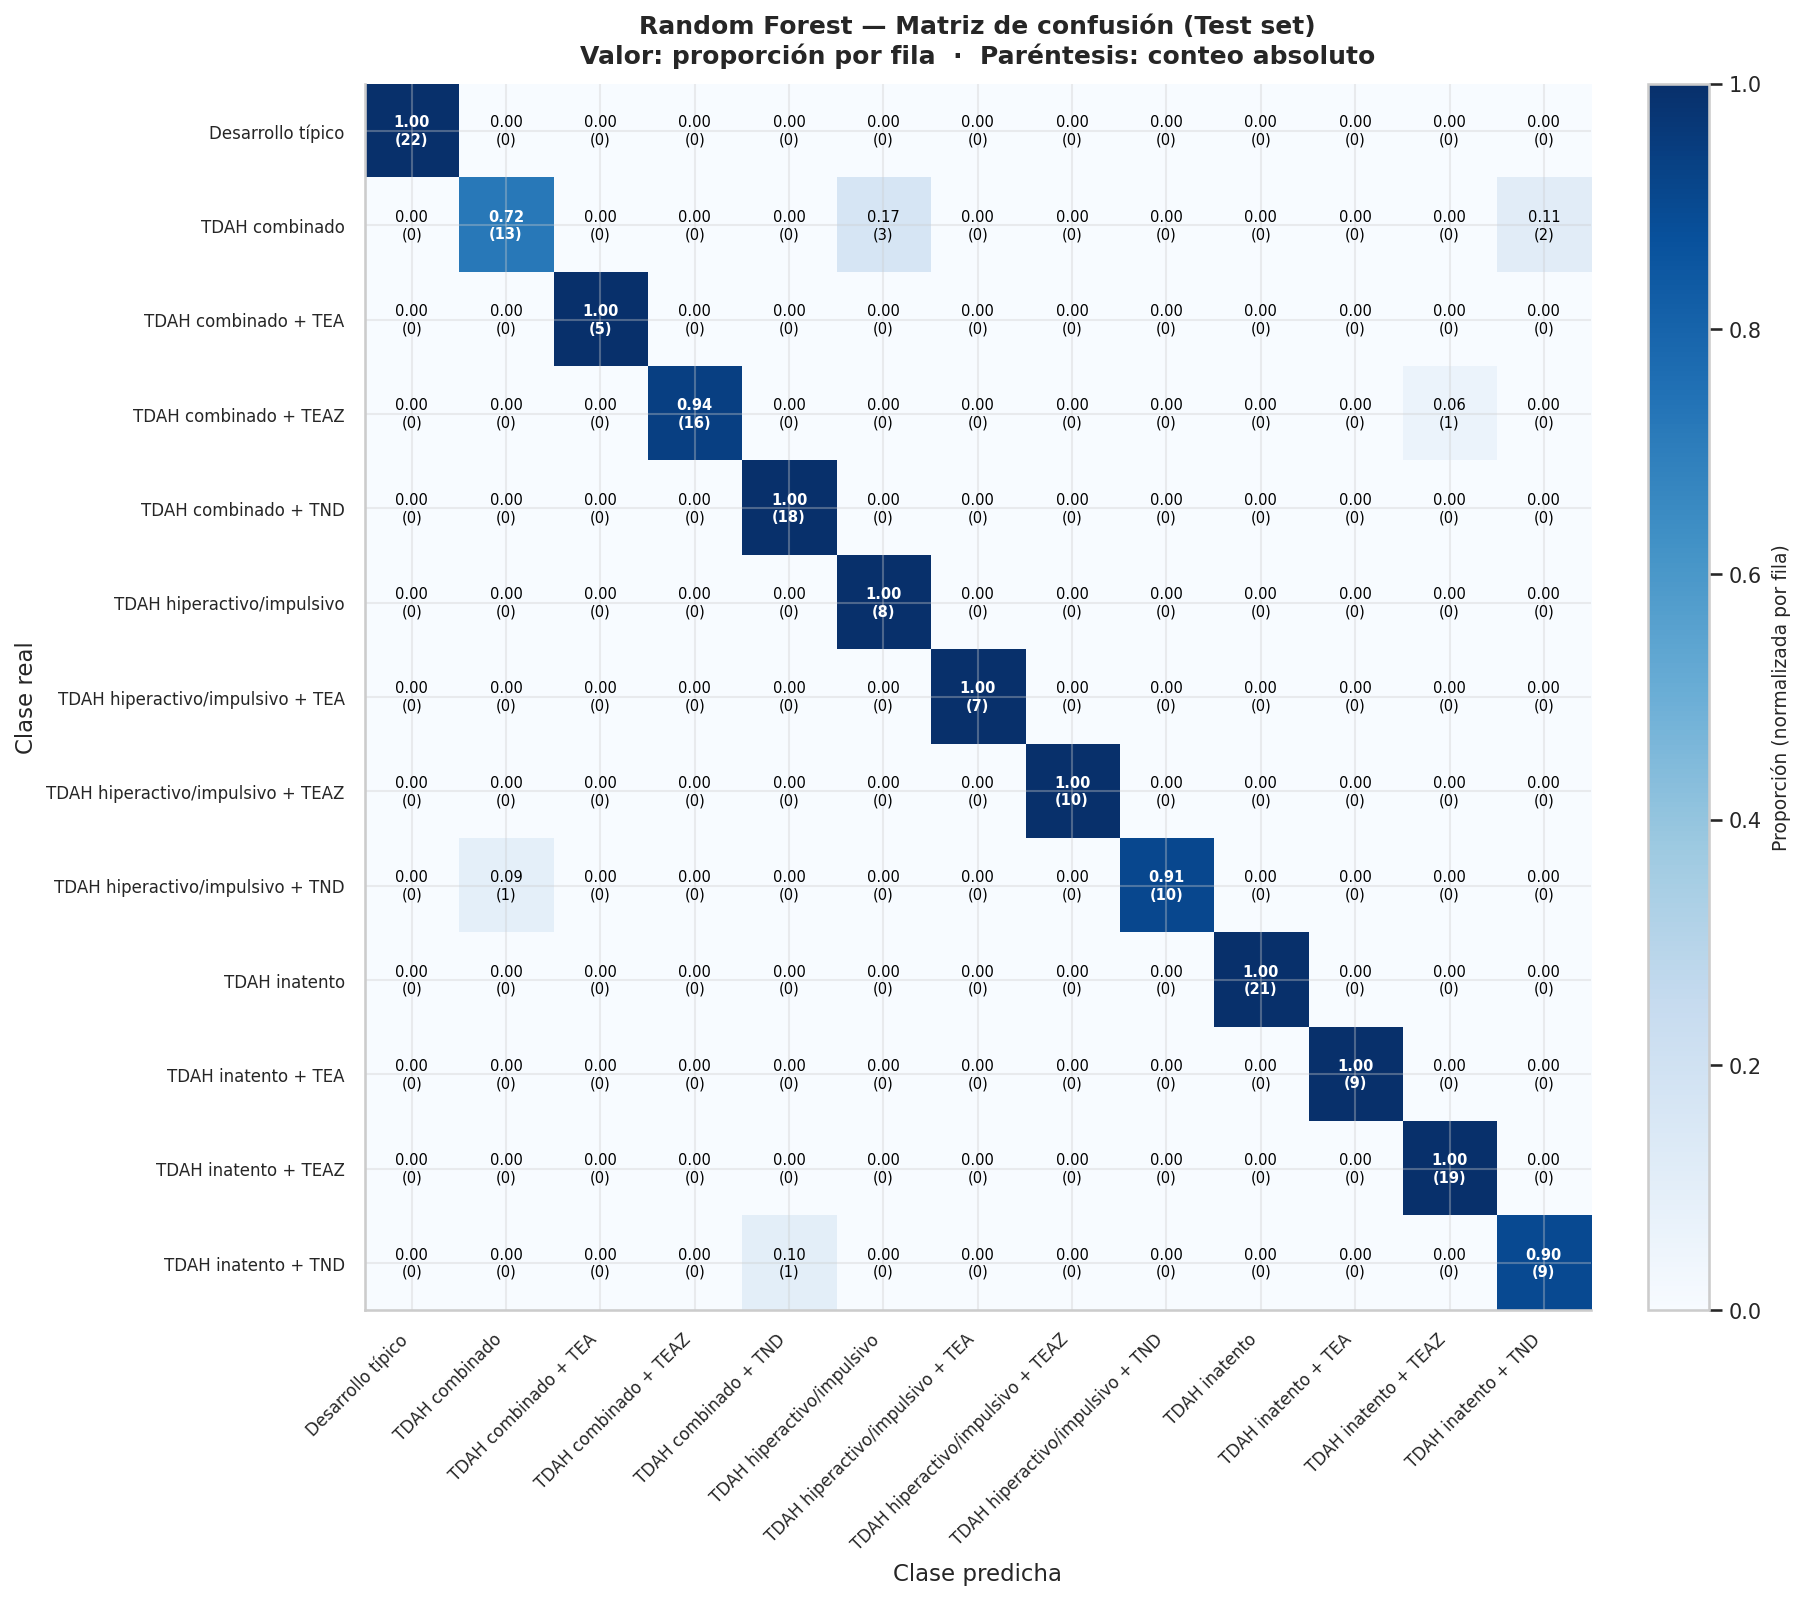

Recall medio (diagonal): 0.959 | Peor clase: 'TDAH combinado' (0.722)


In [15]:
plot_cm(y_test, y_pred_rf, y_labels,
        "Random Forest — Matriz de confusión (Test set)\n"
        "Valor: proporción por fila  ·  Paréntesis: conteo absoluto", cmap='Blues')


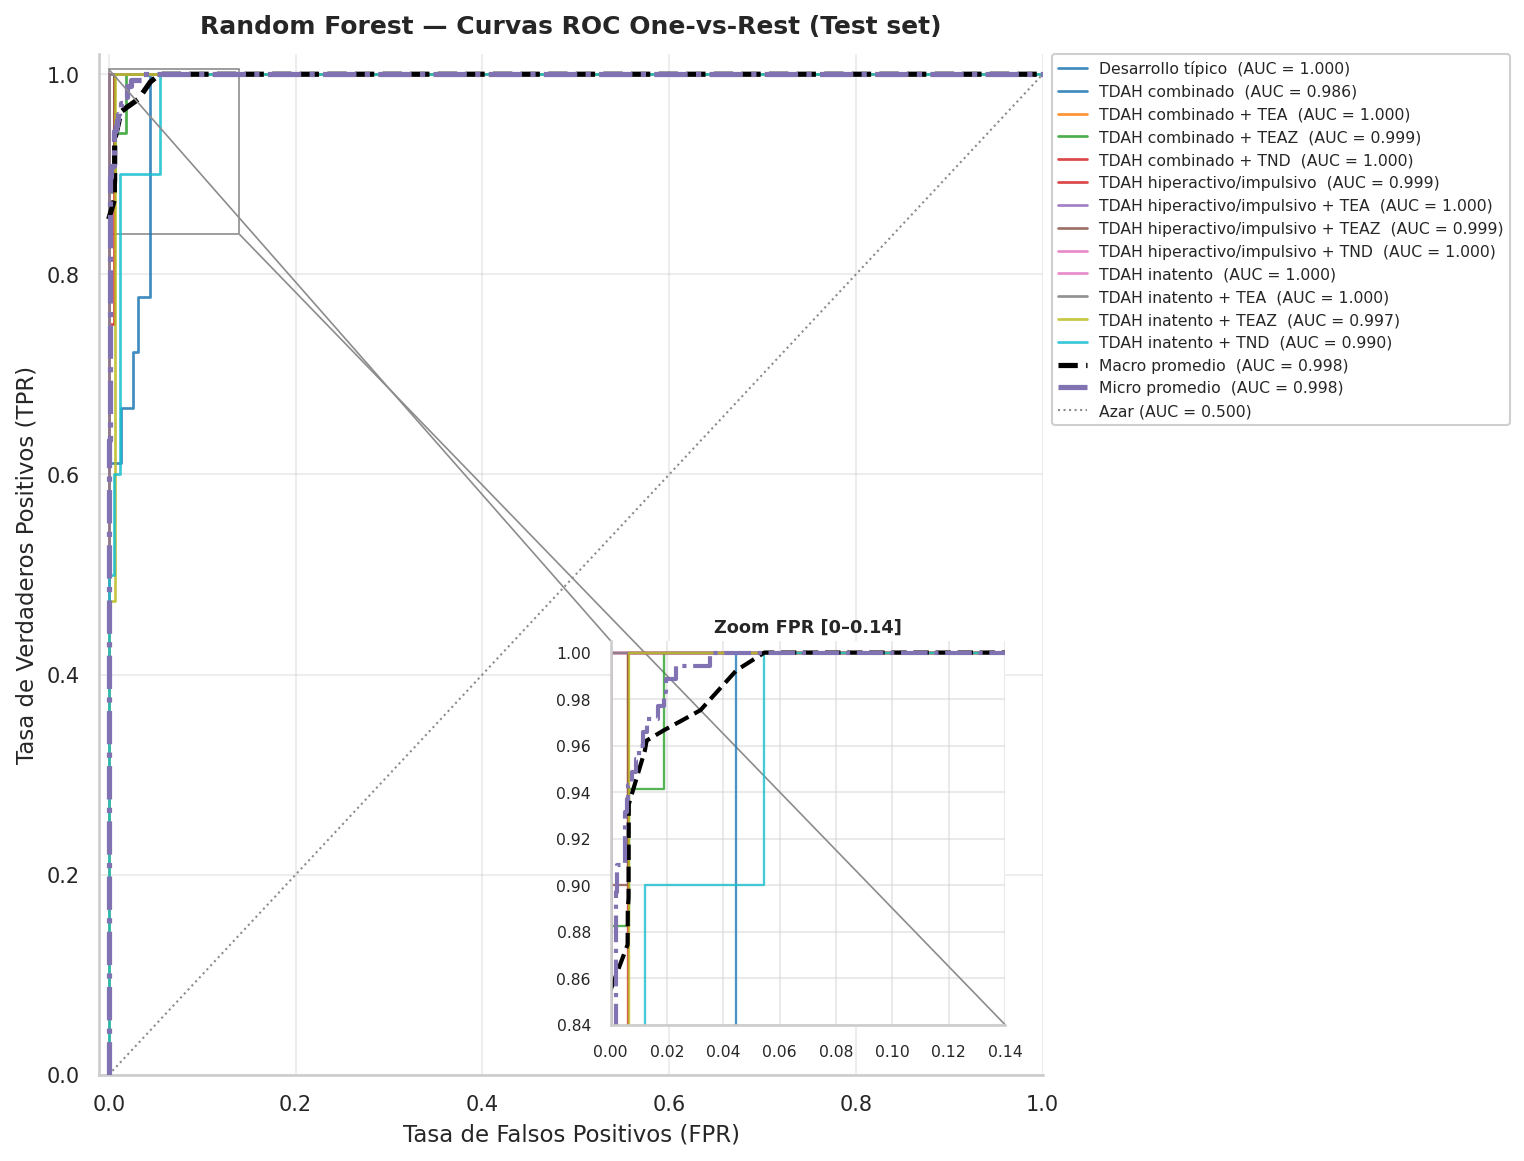


AUC por clase (One-vs-Rest, ordenado):
  Desarrollo típico                                1.0000
  TDAH combinado + TEA                             1.0000
  TDAH combinado + TND                             1.0000
  TDAH hiperactivo/impulsivo + TEA                 1.0000
  TDAH hiperactivo/impulsivo + TND                 1.0000
  TDAH inatento                                    1.0000
  TDAH inatento + TEA                              1.0000
  TDAH hiperactivo/impulsivo + TEAZ                0.9994
  TDAH combinado + TEAZ                            0.9985
  TDAH hiperactivo/impulsivo                       0.9985
  TDAH inatento + TEAZ                             0.9966
  TDAH inatento + TND                              0.9903
  TDAH combinado                                   0.9862

Macro AUC: 0.9980  |  Micro AUC: 0.9984
Clase con menor AUC: 'TDAH combinado' (0.9862)


In [16]:
plot_roc_multiclass(
    y_test, y_proba_rf, y_labels,
    "Random Forest — Curvas ROC One-vs-Rest (Test set)",
    palette=plt.cm.tab10(np.linspace(0, 0.9, len(y_labels))))


📋 **Interpretación — Random Forest**

**Importancia de features:** el resumen impreso arriba muestra los valores exactos. Las barras de error cortas indican que los 300 árboles coinciden en la relevancia de esa variable — señal de robustez. La concentración de importancia en las escalas BASC-3 es esperada: miden directamente los constructos conductuales que definen los subtipos TDAH.

Un patrón saludable es que la importancia esté **distribuida entre varias features** del mismo grupo (BASC-3), en lugar de concentrarse en una sola. Si una única variable acapara >50% de la importancia, merece revisión de proxy. La distribución observada puede verificarse en la tabla impresa arriba.

**Matriz de confusión:** compara con la de la LR (Bloque 4). Una diagonal más oscura y errores fuera de diagonal más pequeños indican mejora. La clase con peor recall (reportada tras la gráfica) es la más difícil de separar con las features disponibles.

**ROC — inset:** el zoom revela que el RF empuja todas las curvas más hacia la esquina superior izquierda respecto a la LR — confirma mejora en discriminación clase a clase.

---
## Bloque 6 — XGBoost

Gradient Boosting secuencial: cada árbol corrige los errores del anterior. Suele superar
a Random Forest en datasets tabulares pequeños/medianos. El desbalance se maneja con
`sample_weight` calculado inversamente a la frecuencia de clase.

La comparación de importancia XGBoost vs Random Forest valida la robustez del ranking de features:
si ambos modelos priorizan las mismas variables, hay evidencia fuerte de que son genuinamente informativas.

In [17]:
sw_train = compute_sample_weight('balanced', y_train)

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='mlogloss', random_state=42,
                    n_jobs=-1, verbosity=0)
cv_res_xgb    = cross_validate(xgb, X_train, y_train, cv=cv5,
                               scoring=['f1_macro','accuracy'])
cv_scores_xgb = cv_res_xgb['test_f1_macro']

print(f"XGB — CV F1-macro: {cv_scores_xgb.mean():.3f} ± {cv_scores_xgb.std():.3f}"
      f"  (folds: {', '.join(f'{v:.3f}' for v in cv_scores_xgb)})")
print(f"XGB — CV Accuracy: {cv_res_xgb['test_accuracy'].mean():.3f}"
      f" ± {cv_res_xgb['test_accuracy'].std():.3f}")

xgb.fit(X_train, y_train, sample_weight=sw_train)
y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)

print("\n=== Reporte en TEST ===")
print(classification_report(y_test, y_pred_xgb, target_names=y_labels, zero_division=0))


XGB — CV F1-macro: 0.934 ± 0.022  (folds: 0.902, 0.968, 0.945, 0.925, 0.928)
XGB — CV Accuracy: 0.940 ± 0.017



=== Reporte en TEST ===
                                   precision    recall  f1-score   support

                Desarrollo típico       1.00      1.00      1.00        22
                   TDAH combinado       0.93      0.72      0.81        18
             TDAH combinado + TEA       0.83      1.00      0.91         5
            TDAH combinado + TEAZ       0.94      0.94      0.94        17
             TDAH combinado + TND       1.00      1.00      1.00        18
       TDAH hiperactivo/impulsivo       0.89      1.00      0.94         8
 TDAH hiperactivo/impulsivo + TEA       1.00      0.86      0.92         7
TDAH hiperactivo/impulsivo + TEAZ       0.90      0.90      0.90        10
 TDAH hiperactivo/impulsivo + TND       1.00      1.00      1.00        11
                    TDAH inatento       1.00      1.00      1.00        21
              TDAH inatento + TEA       1.00      1.00      1.00         9
             TDAH inatento + TEAZ       0.90      1.00      0.95        19

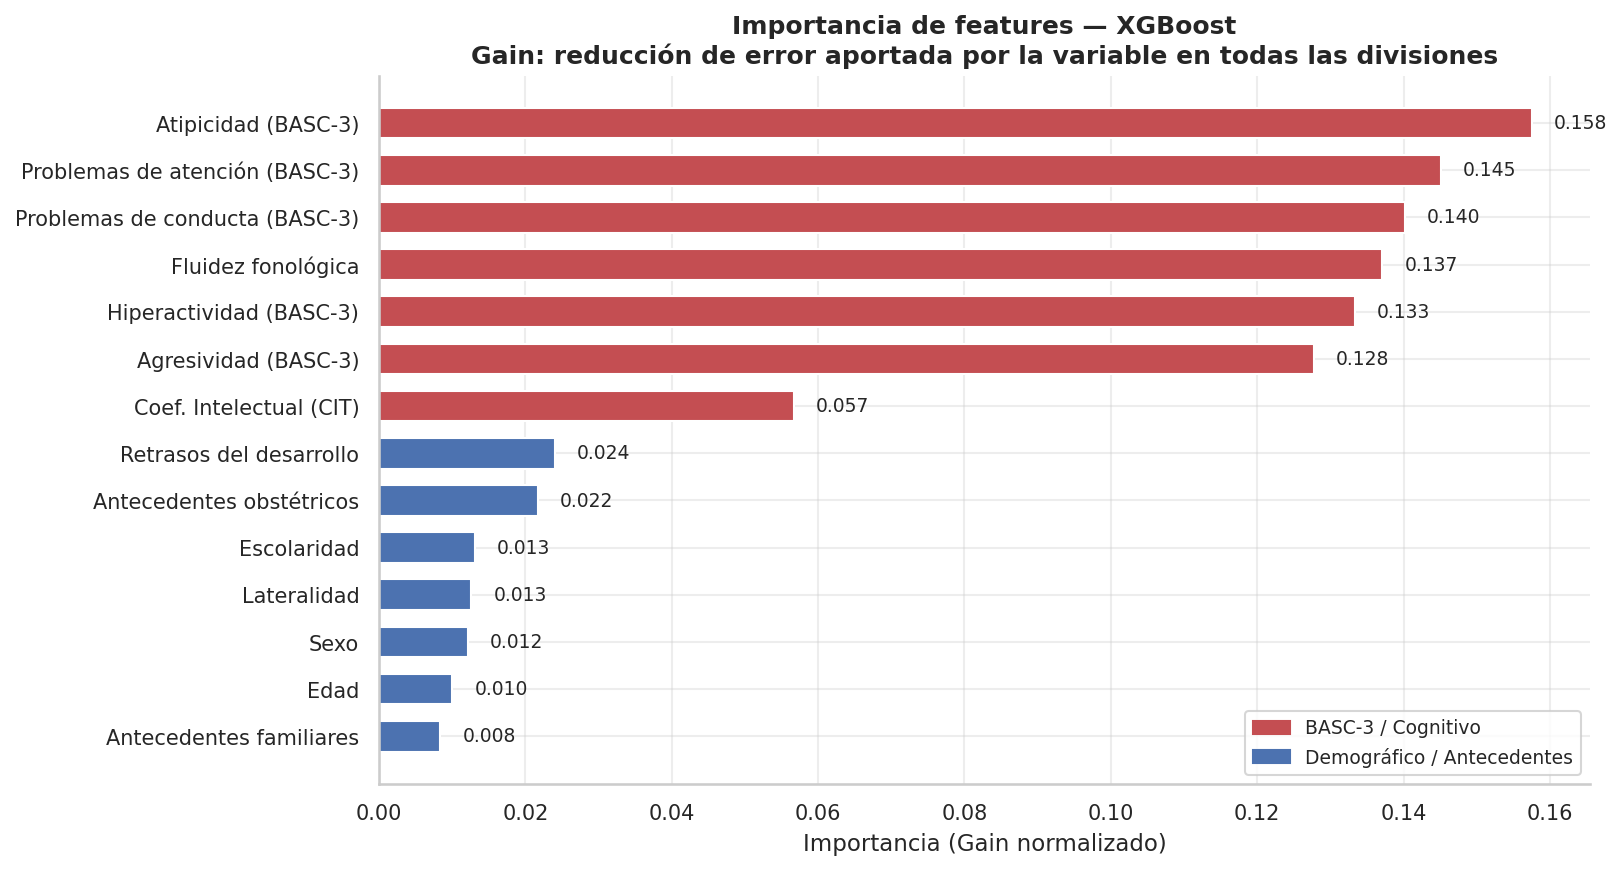


Top 5 RF:   ['Problemas de atención (BASC-3)', 'Problemas de conducta (BASC-3)', 'Hiperactividad (BASC-3)', 'Atipicidad (BASC-3)', 'Agresividad (BASC-3)']
Top 5 XGB:  ['Atipicidad (BASC-3)', 'Problemas de atención (BASC-3)', 'Problemas de conducta (BASC-3)', 'Fluidez fonológica', 'Hiperactividad (BASC-3)']
Coincidencias en top 5: 4/5 — ✅ alta concordancia


In [18]:
imp_xgb = (pd.Series(xgb.feature_importances_, index=FEATURES)
             .sort_values(ascending=True))
labels_xgb = [FEATURE_LABELS.get(f, f) for f in imp_xgb.index]

fig, ax = plt.subplots(figsize=(11, 6))
bar_cols_x = ['#C44E52' if ('basc3' in f or f in ['cit','fluidez_fonologica'])
               else '#4C72B0' for f in imp_xgb.index]
bars = ax.barh(labels_xgb, imp_xgb.values,
               color=bar_cols_x, edgecolor='white', height=0.65)
for bar, val in zip(bars, imp_xgb.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.legend(handles=[p_b, p_d], fontsize=9)
ax.set_xlabel("Importancia (Gain normalizado)", fontsize=11)
ax.set_title("Importancia de features — XGBoost\n"
             "Gain: reducción de error aportada por la variable en todas las divisiones",
             fontsize=12)
plt.tight_layout()
plt.show()

# Comparar ranking top-5 RF vs XGB
top5_rf  = pd.Series(rf.feature_importances_,  index=FEATURES).nlargest(5).index.tolist()
top5_xgb = pd.Series(xgb.feature_importances_, index=FEATURES).nlargest(5).index.tolist()
coinciden = set(top5_rf) & set(top5_xgb)
print(f"\nTop 5 RF:   {[FEATURE_LABELS.get(f,f) for f in top5_rf]}")
print(f"Top 5 XGB:  {[FEATURE_LABELS.get(f,f) for f in top5_xgb]}")
print(f"Coincidencias en top 5: {len(coinciden)}/5 — "
      + ("✅ alta concordancia" if len(coinciden) >= 4 else
         "⚠️ ranking divergente — revisar estabilidad"))


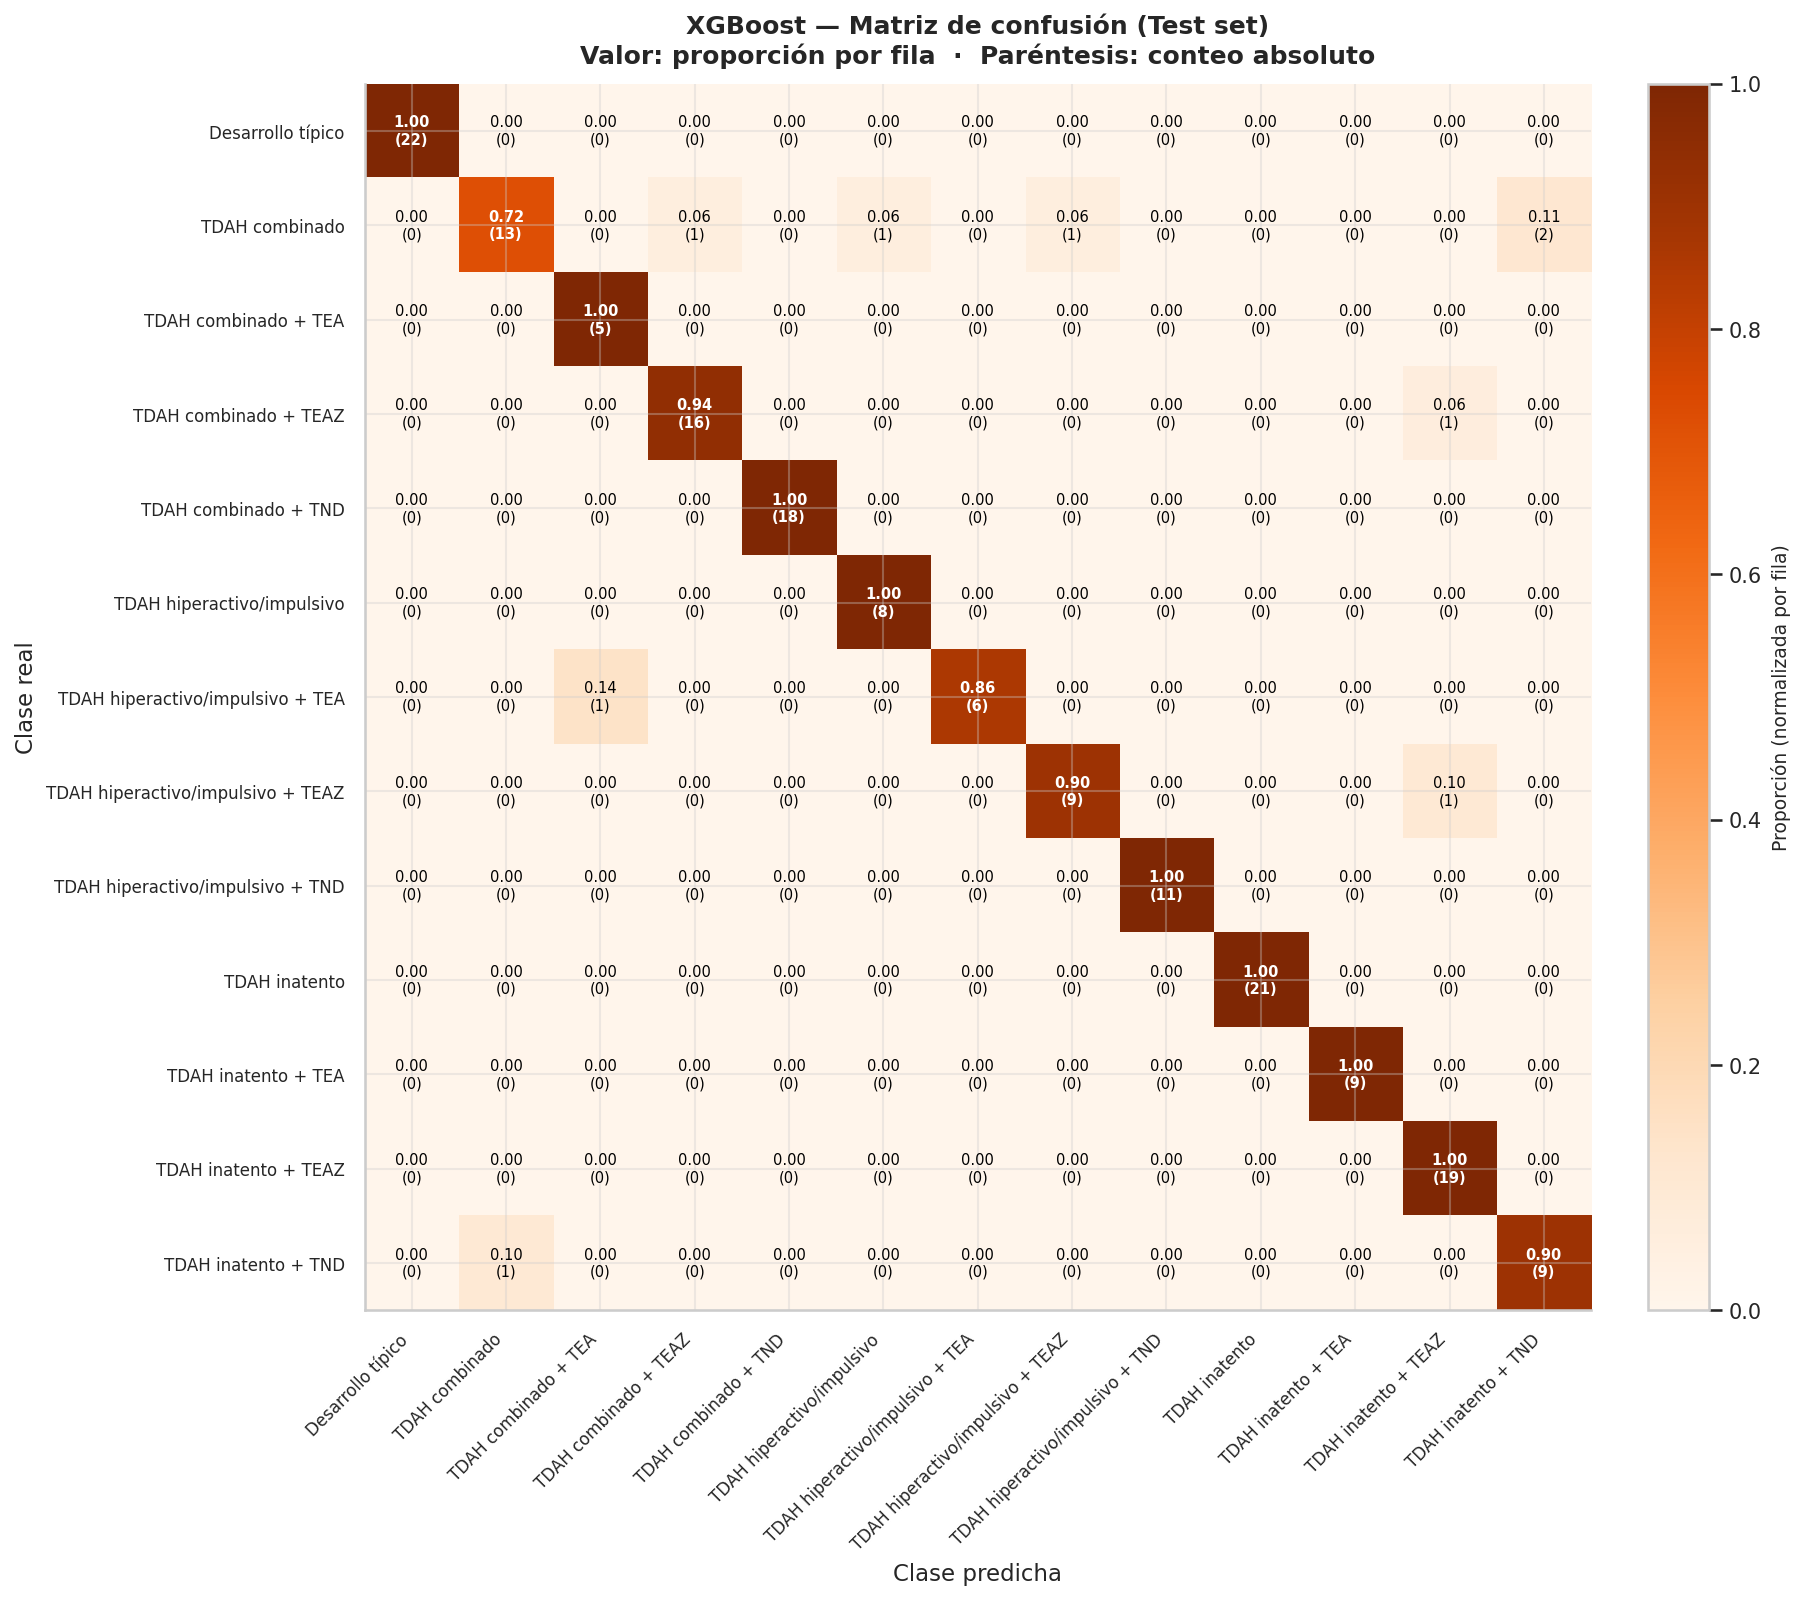

Recall medio (diagonal): 0.948 | Peor clase: 'TDAH combinado' (0.722)


In [19]:
plot_cm(y_test, y_pred_xgb, y_labels,
        "XGBoost — Matriz de confusión (Test set)\n"
        "Valor: proporción por fila  ·  Paréntesis: conteo absoluto", cmap='Oranges')


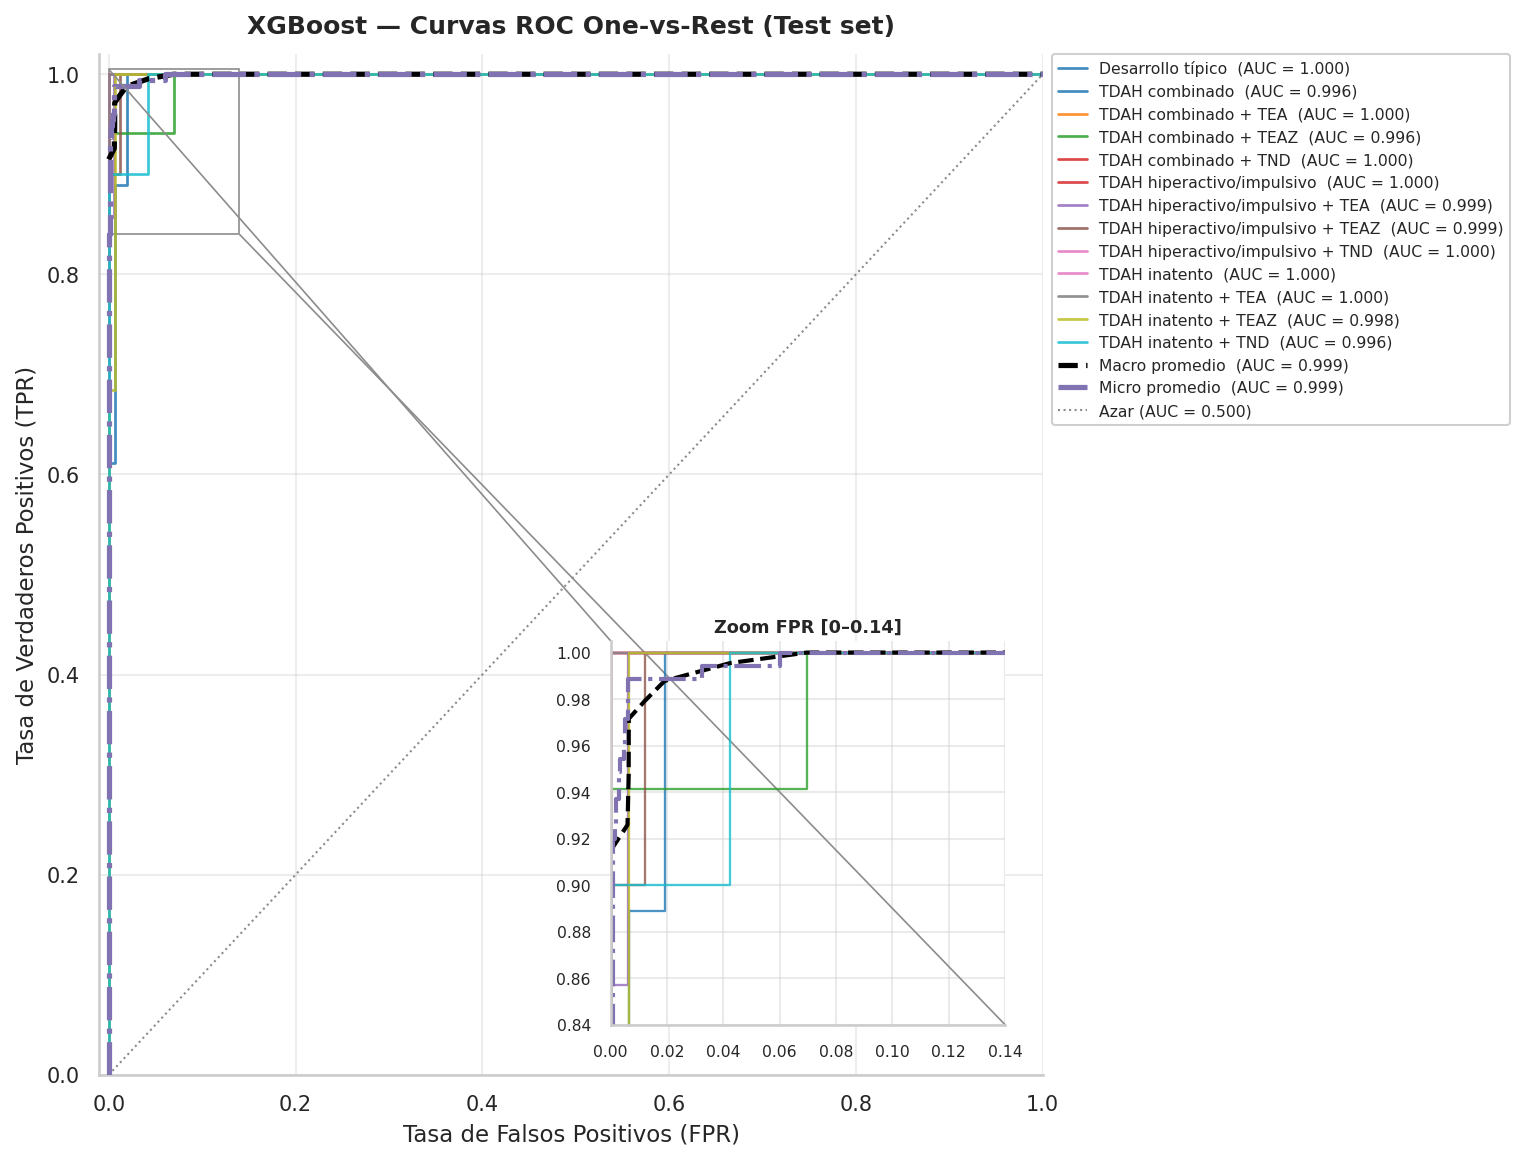


AUC por clase (One-vs-Rest, ordenado):
  Desarrollo típico                                1.0000
  TDAH combinado + TEA                             1.0000
  TDAH combinado + TND                             1.0000
  TDAH hiperactivo/impulsivo                       1.0000
  TDAH hiperactivo/impulsivo + TND                 1.0000
  TDAH inatento                                    1.0000
  TDAH inatento + TEA                              1.0000
  TDAH hiperactivo/impulsivo + TEA                 0.9991
  TDAH hiperactivo/impulsivo + TEAZ                0.9988
  TDAH inatento + TEAZ                             0.9980
  TDAH combinado                                   0.9961
  TDAH combinado + TEAZ                            0.9959
  TDAH inatento + TND                              0.9958

Macro AUC: 0.9990  |  Micro AUC: 0.9991
Clase con menor AUC: 'TDAH inatento + TND' (0.9958)


In [20]:
plot_roc_multiclass(
    y_test, y_proba_xgb, y_labels,
    "XGBoost — Curvas ROC One-vs-Rest (Test set)",
    palette=plt.cm.tab10(np.linspace(0, 0.9, len(y_labels))))


📋 **Interpretación — XGBoost**

XGBoost tiende a concentrar la importancia (Gain) en las features que aportan mayor reducción de error en las primeras ramas del boosting. Comparar con el ranking del RF: si coinciden en el top 4–5, hay evidencia sólida de que esas variables son genuinamente informativas y no artefactos de un algoritmo específico (resultado impreso arriba).

Diferencias entre los rankings de ambos modelos no necesariamente indican un problema: RF mide impacto promedio en árboles independientes, XGB mide impacto acumulado en árboles secuenciales. Las features con importancia baja en ambos (demográficas, antecedentes) aportan marginalmente pero de forma aditiva.

---
## Bloque 7 — Comparación de modelos y conclusiones

Consolidación de todas las métricas. La tabla incluye media ± std del CV
y la evaluación final en el test set. El gráfico permite comparar visualmente
la estabilidad (barras de error) y la brecha entre CV y test (sobreajuste).

In [21]:
results = {
    'Logistic Regression': dict(
        cv_f1=cv_scores_lr,    cv_acc=cv_res_lr['test_accuracy'],
        y_pred=y_pred_lr,      y_proba=y_proba_lr),
    'Random Forest':       dict(
        cv_f1=cv_scores_rf,    cv_acc=cv_res_rf['test_accuracy'],
        y_pred=y_pred_rf,      y_proba=y_proba_rf),
    'XGBoost':             dict(
        cv_f1=cv_scores_xgb,   cv_acc=cv_res_xgb['test_accuracy'],
        y_pred=y_pred_xgb,     y_proba=y_proba_xgb),
}

rows = []
for name, d in results.items():
    tf1  = f1_score(y_test, d['y_pred'], average='macro', zero_division=0)
    tacc = accuracy_score(y_test, d['y_pred'])
    gap  = abs(d['cv_f1'].mean() - tf1)
    rows.append({'Modelo': name,
                 'CV F1-macro': f"{d['cv_f1'].mean():.3f} ± {d['cv_f1'].std():.3f}",
                 'CV Accuracy': f"{d['cv_acc'].mean():.3f} ± {d['cv_acc'].std():.3f}",
                 'Test F1-macro': round(tf1, 3),
                 'Test Accuracy': round(tacc, 3),
                 'Brecha CV→Test': round(gap, 3)})

summary_df = pd.DataFrame(rows).set_index('Modelo')
print(summary_df.to_string())
best_model = summary_df['Test F1-macro'].idxmax()
print(f"\nMejor modelo (Test F1-macro): {best_model}")
print(f"Brecha máxima aceptable: 0.05 | "
      + ("✅ Todos los modelos generalizan correctamente"
         if summary_df['Brecha CV→Test'].max() < 0.05
         else "⚠️ Algún modelo muestra sobreajuste"))


                       CV F1-macro    CV Accuracy  Test F1-macro  Test Accuracy  Brecha CV→Test
Modelo                                                                                         
Logistic Regression  0.841 ± 0.024  0.864 ± 0.020          0.851          0.874           0.011
Random Forest        0.953 ± 0.018  0.953 ± 0.015          0.952          0.954           0.001
XGBoost              0.934 ± 0.022  0.940 ± 0.017          0.941          0.949           0.008

Mejor modelo (Test F1-macro): Random Forest
Brecha máxima aceptable: 0.05 | ✅ Todos los modelos generalizan correctamente


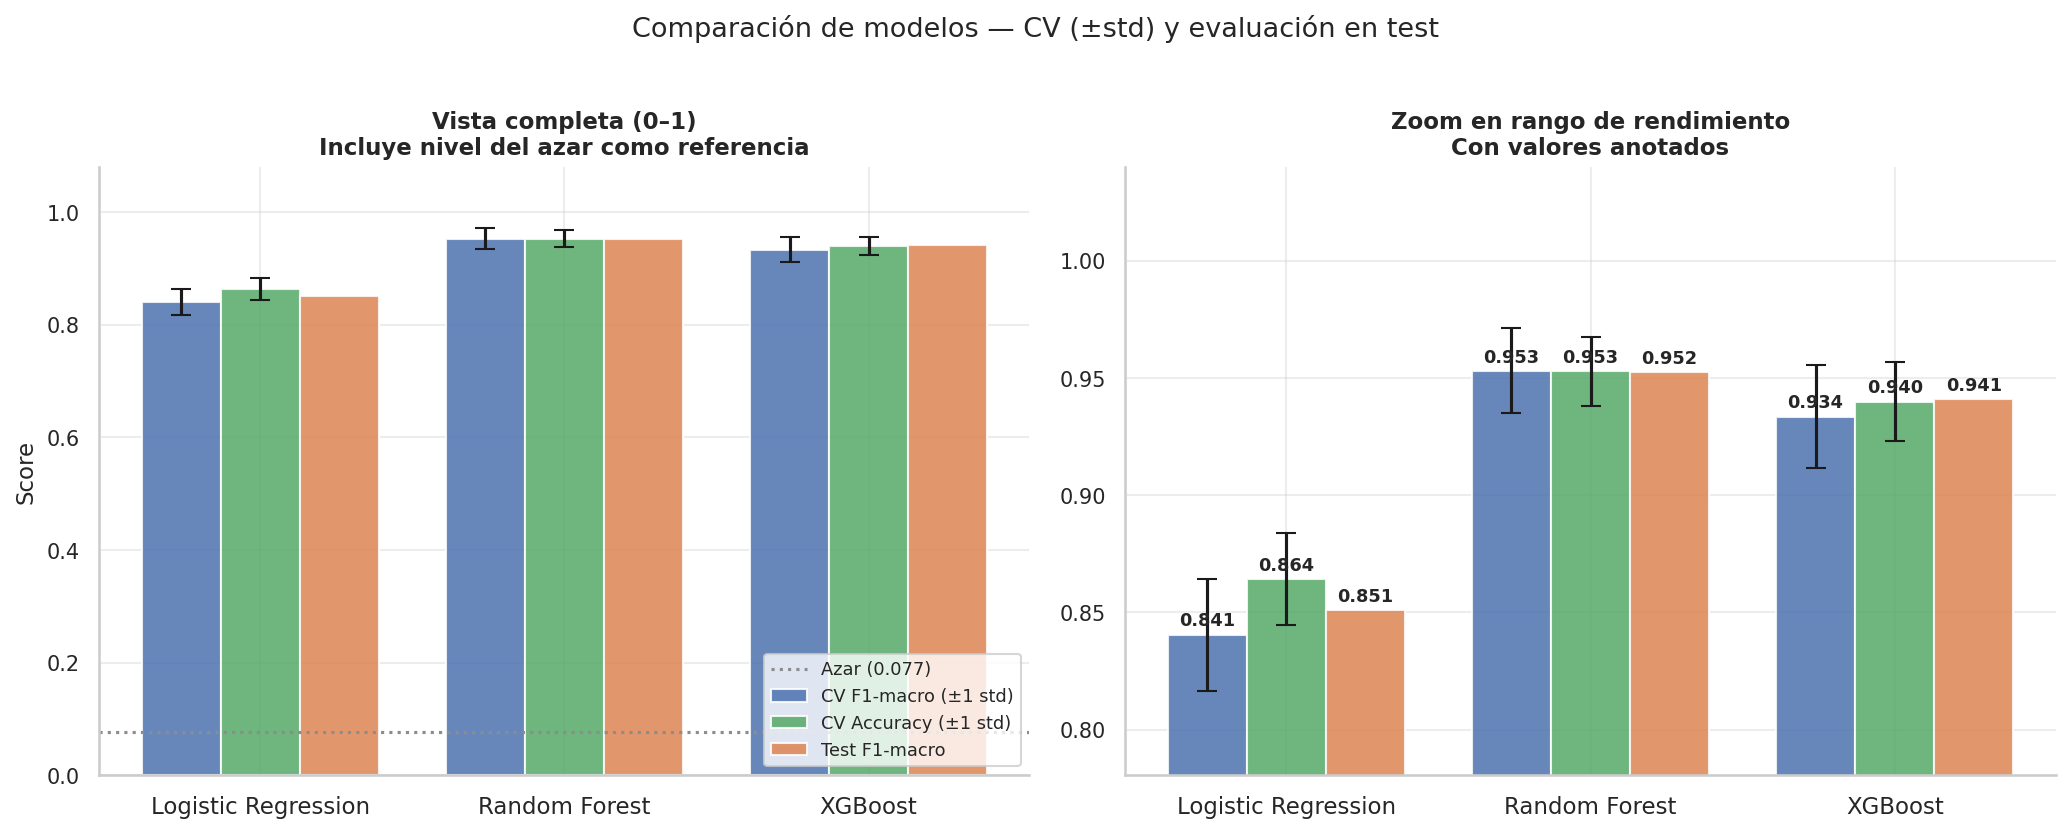

In [22]:
# ── Gráfica comparativa con barras de error y escala 0–1 completa ────────────
names  = list(results.keys())
short  = ['LR', 'RF', 'XGB']
x      = np.arange(len(names))
w      = 0.26

cv_f1_m  = [results[n]['cv_f1'].mean()   for n in names]
cv_f1_s  = [results[n]['cv_f1'].std()    for n in names]
cv_acc_m = [results[n]['cv_acc'].mean()  for n in names]
cv_acc_s = [results[n]['cv_acc'].std()   for n in names]
te_f1    = [f1_score(y_test, results[n]['y_pred'], average='macro', zero_division=0)
             for n in names]
chance   = 1 / len(y_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel izquierdo: vista completa 0-1 con nivel del azar
ax = axes[0]
b1 = ax.bar(x - w, cv_f1_m,  w, yerr=cv_f1_s,  capsize=5,
            color=C_BLUE, alpha=0.85, edgecolor='white', label='CV F1-macro (±1 std)')
b2 = ax.bar(x,     cv_acc_m, w, yerr=cv_acc_s, capsize=5,
            color=C_GRN,  alpha=0.85, edgecolor='white', label='CV Accuracy (±1 std)')
b3 = ax.bar(x + w, te_f1,    w,
            color=C_ORG,  alpha=0.85, edgecolor='white', label='Test F1-macro')
ax.axhline(chance, color=C_GRAY, linestyle=':', lw=1.5,
           label=f'Azar ({chance:.3f})')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.08)
ax.set_title("Vista completa (0–1)\nIncluye nivel del azar como referencia", fontsize=11)
ax.legend(fontsize=8.5, loc='lower right')

# Panel derecho: zoom en rango relevante con anotaciones
ax2 = axes[1]
lo = max(0, min(cv_f1_m + cv_acc_m + te_f1) - 0.06)
b1b = ax2.bar(x - w, cv_f1_m,  w, yerr=cv_f1_s,  capsize=5,
              color=C_BLUE, alpha=0.85, edgecolor='white')
b2b = ax2.bar(x,     cv_acc_m, w, yerr=cv_acc_s, capsize=5,
              color=C_GRN,  alpha=0.85, edgecolor='white')
b3b = ax2.bar(x + w, te_f1,    w,
              color=C_ORG,  alpha=0.85, edgecolor='white')
for bars in [b1b, b2b, b3b]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.002,
                 f'{h:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(names, fontsize=11)
ax2.set_ylim(lo, 1.04)
ax2.set_title("Zoom en rango de rendimiento\nCon valores anotados", fontsize=11)

plt.suptitle("Comparación de modelos — CV (±std) y evaluación en test", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


📋 **Interpretación — Comparación de modelos**

**Panel izquierdo (escala 0–1):** permite apreciar cuánto superan los modelos al nivel del azar. Todos los modelos lo superan ampliamente, lo que confirma que las features capturan información real sobre el diagnóstico.

**Panel derecho (zoom):** muestra las diferencias entre modelos con valores anotados. Los modelos no lineales (RF y XGBoost) superan al baseline lineal (LR), validando que las relaciones entre variables son en parte no lineales.

**Brecha CV → Test F1-macro:** reportada en la tabla arriba. Una brecha < 0.05 indica generalización correcta; una brecha mayor indicaría sobreajuste. La desviación estándar del CV complementa este análisis: una std alta significa que el rendimiento varía según qué fold se usa como validación — señal de sensibilidad a los datos de entrenamiento.

**Modelo recomendado:** el de mayor Test F1-macro con menor brecha. En contexto clínico, un modelo ligeramente menos preciso pero más interpretable (RF con importancia de features + barras de error) puede preferirse sobre una diferencia marginal de F1.

---
## Bloque 8 — Análisis de errores por comorbilidad

Identificar en qué categorías diagnósticas falla el mejor modelo y por qué es clave para entender las limitaciones clínicas del sistema.

In [23]:
scores_test = {n: f1_score(y_test, results[n]['y_pred'], average='macro', zero_division=0)
               for n in results}
best_name   = max(scores_test, key=scores_test.get)
best_pred   = results[best_name]['y_pred']
best_proba  = results[best_name]['y_proba']
print(f"Mejor modelo: {best_name}  (Test F1-macro = {scores_test[best_name]:.3f})")

rep = classification_report(y_test, best_pred, target_names=y_labels,
                             output_dict=True, zero_division=0)
met = pd.DataFrame({k: v for k, v in rep.items() if k in y_labels}).T
met['n_test'] = (pd.Series(y_test)
                   .value_counts()
                   .rename(dict(enumerate(y_labels)))
                   .reindex(met.index))
met = met.sort_values('f1-score')
print("\nMétricas por clase (ordenadas por F1, peor primero):")
print(met[['precision','recall','f1-score','n_test']].round(3).to_string())
print(f"\nClases con F1 < 0.70 (clasificación débil):")
weak = met[met['f1-score'] < 0.70]
if len(weak):
    for cls, row in weak.iterrows():
        print(f"  {cls:<48} F1={row['f1-score']:.3f}  n_test={int(row['n_test'])}")
else:
    print("  Ninguna — todas las clases tienen F1 ≥ 0.70")


Mejor modelo: Random Forest  (Test F1-macro = 0.952)



Métricas por clase (ordenadas por F1, peor primero):
                                   precision  recall  f1-score  n_test
TDAH combinado                         0.929   0.722     0.812      18
TDAH hiperactivo/impulsivo             0.727   1.000     0.842       8
TDAH inatento + TND                    0.818   0.900     0.857      10
TDAH hiperactivo/impulsivo + TND       1.000   0.909     0.952      11
TDAH combinado + TEAZ                  1.000   0.941     0.970      17
TDAH combinado + TND                   0.947   1.000     0.973      18
TDAH inatento + TEAZ                   0.950   1.000     0.974      19
Desarrollo típico                      1.000   1.000     1.000      22
TDAH combinado + TEA                   1.000   1.000     1.000       5
TDAH hiperactivo/impulsivo + TEA       1.000   1.000     1.000       7
TDAH hiperactivo/impulsivo + TEAZ      1.000   1.000     1.000      10
TDAH inatento                          1.000   1.000     1.000      21
TDAH inatento + TEA    

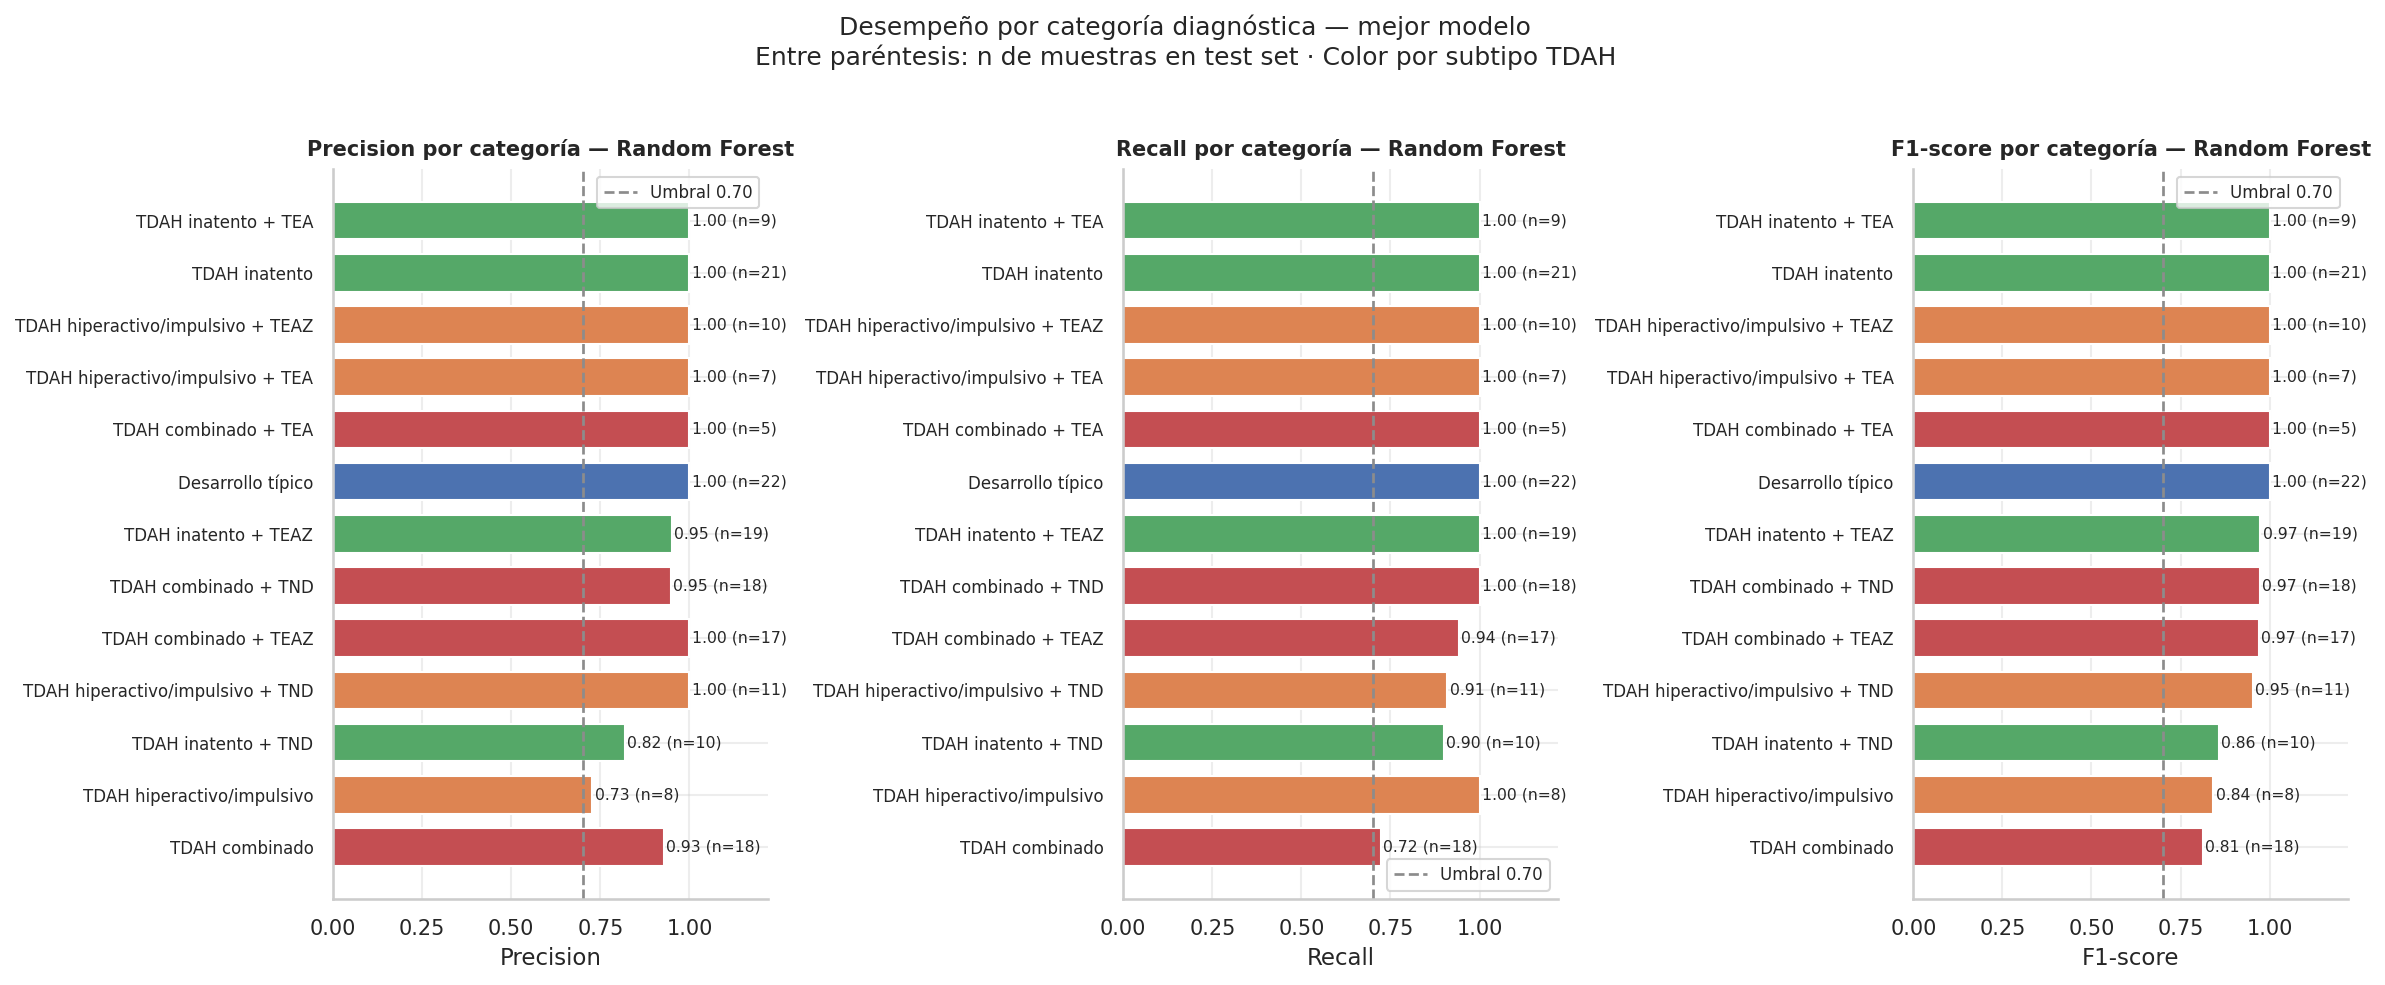

In [24]:
def subtype_color_list(labels):
    return [subtype_color(l) for l in labels]

fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))
for ax, (metric, label) in zip(axes,
        [('precision','Precision'), ('recall','Recall'), ('f1-score','F1-score')]):
    vals   = met[metric]
    colors = subtype_color_list(met.index)
    bars   = ax.barh(met.index, vals, color=colors, edgecolor='white', height=0.72)
    for bar, v, n_t in zip(bars, vals, met['n_test']):
        ax.text(v + 0.007, bar.get_y() + bar.get_height()/2,
                f'{v:.2f} (n={int(n_t)})', va='center', fontsize=7.5)
    ax.axvline(0.70, color=C_GRAY, linestyle='--', lw=1.3, label='Umbral 0.70')
    ax.set_xlim(0, 1.22)
    ax.set_xlabel(label, fontsize=11)
    ax.set_title(f"{label} por categoría — {best_name}", fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8)
plt.suptitle("Desempeño por categoría diagnóstica — mejor modelo\n"
             "Entre paréntesis: n de muestras en test set · Color por subtipo TDAH",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


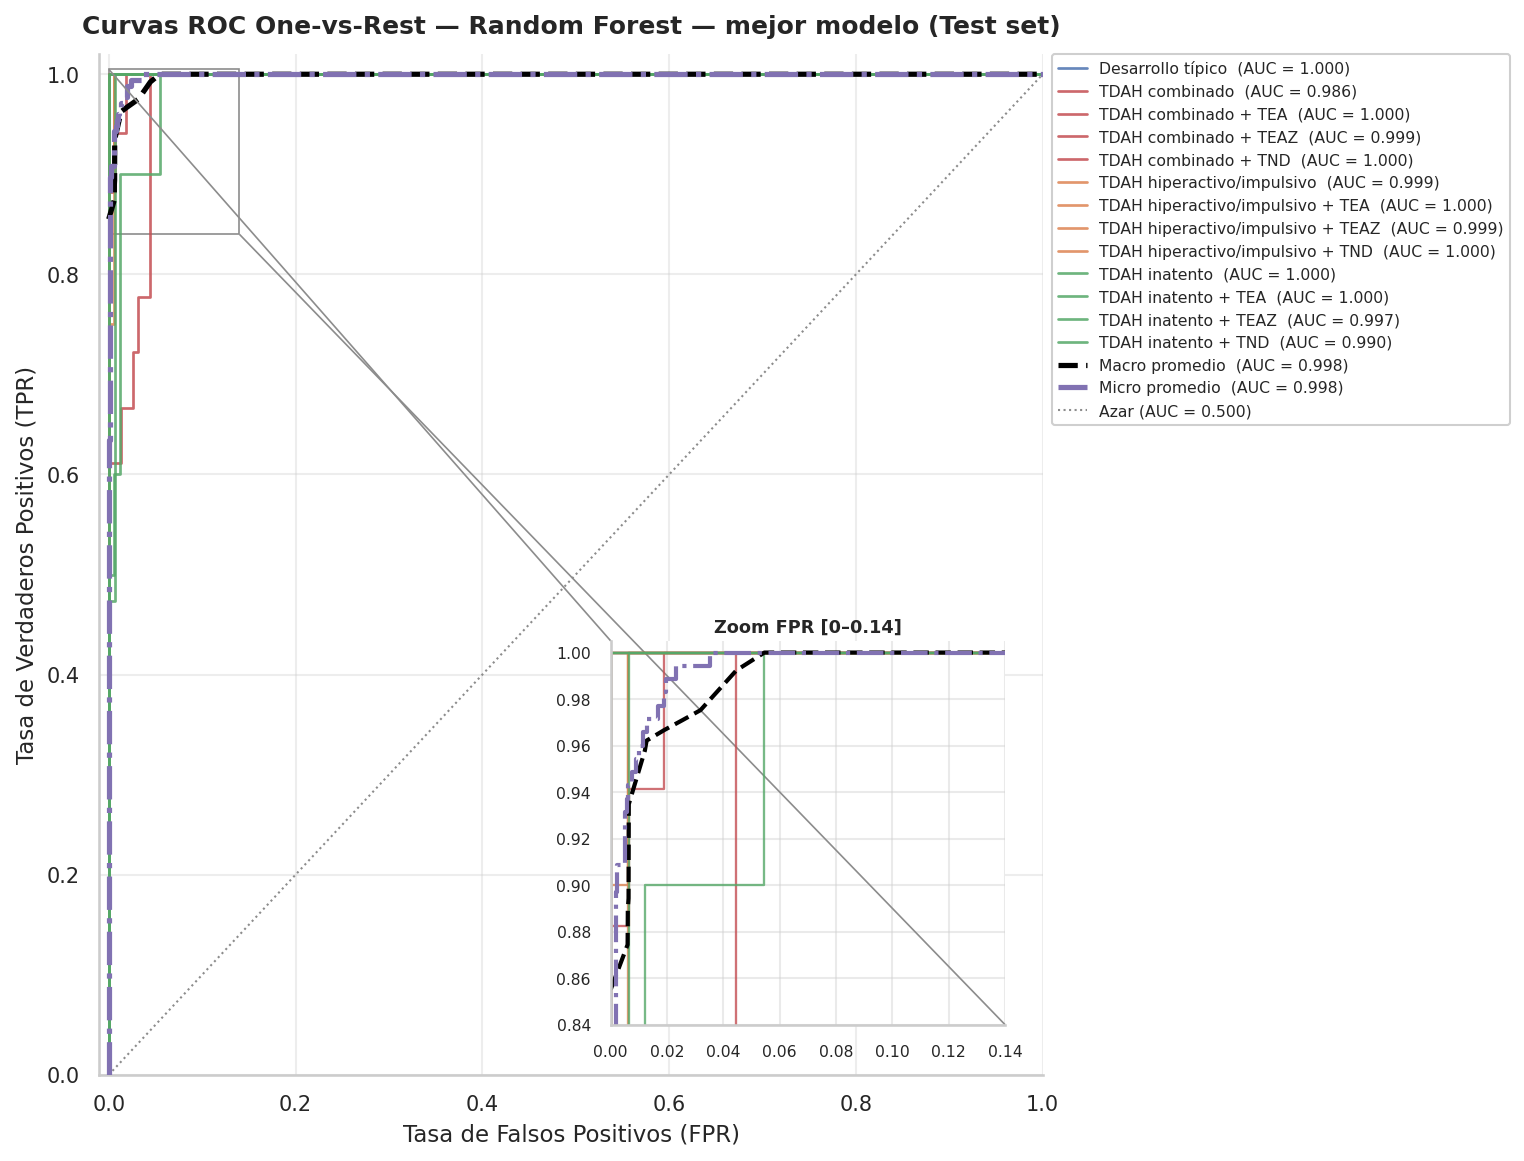


AUC por clase (One-vs-Rest, ordenado):
  Desarrollo típico                                1.0000
  TDAH combinado + TEA                             1.0000
  TDAH combinado + TND                             1.0000
  TDAH hiperactivo/impulsivo + TEA                 1.0000
  TDAH hiperactivo/impulsivo + TND                 1.0000
  TDAH inatento                                    1.0000
  TDAH inatento + TEA                              1.0000
  TDAH hiperactivo/impulsivo + TEAZ                0.9994
  TDAH combinado + TEAZ                            0.9985
  TDAH hiperactivo/impulsivo                       0.9985
  TDAH inatento + TEAZ                             0.9966
  TDAH inatento + TND                              0.9903
  TDAH combinado                                   0.9862

Macro AUC: 0.9980  |  Micro AUC: 0.9984
Clase con menor AUC: 'TDAH combinado' (0.9862)


In [25]:
palette_13 = subtype_color_list(y_labels)
plot_roc_multiclass(
    y_test, best_proba, y_labels,
    f"Curvas ROC One-vs-Rest — {best_name} — mejor modelo (Test set)",
    palette=palette_13)


📋 **Interpretación — Errores por comorbilidad**

**Lectura de las tres métricas:**
- **Precision:** de los casos que el modelo predice como esta categoría, ¿qué fracción realmente lo es? Precision baja → el modelo "inventa" esta categoría para casos que son otra cosa.
- **Recall:** de los casos reales de esta categoría, ¿qué fracción detecta el modelo? Recall bajo → el modelo "pierde" muchos casos reales de esta categoría.
- **F1-score:** media armónica de las dos anteriores. El indicador sintético de rendimiento por clase.

El número entre paréntesis `(n=X)` es la cantidad de muestras de esa clase en el test set — clases con n<10 tienen estimaciones F1 muy ruidosas (±0.10 por cada predicción correcta o incorrecta).

**Patrones esperados por subtipo:**
- **Azul (Desarrollo típico):** recall alto — su perfil BASC-3 (T-scores bajos en todas las escalas) es el más diferenciado del resto.
- **Verde (Inatento):** bien separado en dimensión de atención; se confunde principalmente con Combinado en casos borderline.
- **Naranja (Hiperactivo/impulsivo):** bien separado en dimensión de hiperactividad; errores similares al anterior.
- **Rojo (Combinado + comorbilidad):** los más difíciles — comparten perfil BASC-3 con los inatentos y hiperactivos, y la comorbilidad añade varianza adicional.

**ROC por subtipo:** el AUC más bajo (reportado en la tabla tras la gráfica) identifica qué categoría es más difícil de separar del resto con las 14 features disponibles. Mejorar esa clase requeriría features adicionales específicas.